### Роль RDKit в работе

**RDKit** используется как инструмент для работы с химической структурой молекул. В нашем проекте он выполняет три основные задачи:

1. **Проверка SMILES** — определяет, соответствует ли строка корректной химической структуре.
2. **Работа со структурой молекулы** — позволяет преобразовать SMILES в объект молекулы и анализировать его.
3. **Проверка результатов VAE** — после генерации новых SMILES с помощью VAE RDKit позволит определить, какие из них являются валидными молекулами.

Таким образом, **VAE отвечает за генерацию новых молекулярных структур, а RDKit — за их химическую обработку и проверку**.


In [ ]:
from datasets import load_dataset

ds = load_dataset("edmanft/zinc250k")

### Описание данных датасета ZINC250K

Датасет содержит около 250 тысяч молекул. Для каждой молекулы представлены структурные представления и несколько рассчитанных молекулярных свойств.

* **`index`** — порядковый индекс записи в датасете. Не является химическим свойством молекулы и не используется в качестве входного признака для VAE.

* **`smiles`** — структурное представление молекулы в формате **SMILES (Simplified Molecular Input Line Entry System)**. Молекула записывается в виде строки символов, например `CCO`. В рамках данной работы `SMILES` является основным представлением молекул, которое будет использоваться для обучения генеративной модели.

* **`selfies`** — представление молекулы в формате **SELFIES (Self-Referencing Embedded Strings)**. Это альтернативный способ кодирования молекулярной структуры, разработанный с учётом получения синтаксически корректных молекулярных строк при генерации. В данной работе этот столбец может использоваться для сравнения с представлением SMILES.

* **`logP`** — коэффициент распределения вещества между органической и водной фазами в логарифмической шкале. Используется как характеристика **липофильности (гидрофобности)** молекулы. Чем выше значение `logP`, тем в среднем более липофильной является молекула.

* **`qed`** — количественная оценка **drug-likeness**, то есть соответствия молекулы некоторым свойствам, характерным для лекарственных соединений. Значение рассчитывается по совокупности молекулярных характеристик. Обычно находится в диапазоне от 0 до 1, где большее значение соответствует более высокому показателю drug-likeness.

* **`SAS`** — **Synthetic Accessibility Score**, оценка сложности синтеза молекулы. Показатель характеризует, насколько молекулу сложно получить химическим синтезом с учётом особенностей её структуры. Меньшее значение обычно соответствует более простой синтетической доступности, а большее — более сложной.

В данной работе столбец **`smiles`** будет использоваться как основное входное представление молекул для обучения VAE. Столбцы `logP`, `qed` и `SAS` будут использоваться для анализа свойств исходных и сгенерированных молекул. Столбцы `index` и, на первом этапе, `selfies` непосредственно в качестве входа стандартного VAE использоваться не будут.


Липофильность (гидрофобность) — это способность вещества лучше растворяться в жирах и органических растворителях, чем в воде.

Проще:

высокая липофильность → молекула плохо взаимодействует с водой, лучше — с жирами;
низкая липофильность → молекула лучше взаимодействует с водой.

Для logP: чем выше logP, тем более липофильной обычно является молекула.

#Генерация новых молекулярных структур с использованием условного вариационного автоэнкодера

## 1. Цель работы

Целью работы является разработка и исследование генеративной модели на основе условного вариационного автоэнкодера (Conditional Variational Autoencoder, Conditional VAE) для генерации новых молекулярных структур с возможностью управления их целевыми физико-химическими характеристиками.

В качестве исходного набора данных используется база **ZINC250K**, содержащая около 250 тысяч органических молекул.

Основная идея метода заключается в том, что молекулярная структура преобразуется в последовательное представление **SELFIES**, после чего с помощью нейронной сети строится компактное вероятностное латентное представление молекулы. Затем Transformer Decoder восстанавливает последовательность SELFIES, соответствующую молекулярной структуре.

В разработанной модели дополнительно используются молекулярные дескрипторы. Они применяются в двух направлениях:

1. Encoder получает дескрипторы исходной молекулы вместе с её структурой;
2. Decoder дополнительно получает целевые значения дескрипторов, которые используются как условие генерации.

Таким образом, модель позволяет не только генерировать новые молекулярные структуры из латентного пространства, но и исследовать возможность управления свойствами генерируемых молекул.

В отличие от обычного VAE, при генерации можно задавать значения одного или нескольких целевых дескрипторов. Если задан только один дескриптор, остальные параметры заполняются средними значениями соответствующих признаков обучающей выборки.

---

## 2. Исходные данные

В работе используется набор данных **ZINC250K**.

Для каждой молекулы доступны следующие основные характеристики:

* `smiles` — молекулярная структура в формате SMILES;
* `selfies` — молекулярная структура в формате SELFIES;
* `logP` — коэффициент распределения, характеризующий липофильность;
* `qed` — количественная оценка лекарственноподобия;
* `SAS` — оценка синтетической доступности.

Перед использованием данных выполняется предварительная обработка и фильтрация молекул.

Для исключения нежелательных структур используются несколько критериев:

* соответствие правилам Lipinski;
* соответствие правилам Veber;
* отсутствие структурных предупреждений PAINS;
* допустимый набор химических элементов;
* корректность молекулярной структуры.

После фильтрации сформированный набор данных сохраняется в файл:

`zinc250k_filtered.parquet`

В дальнейшем обучение Conditional VAE выполняется уже на подготовленном наборе данных.

---

## 3. Представление молекул в формате SELFIES

Для представления молекулярных структур используется формат **SELFIES (Self-Referencing Embedded Strings)**.

SELFIES является последовательным представлением молекулы, подобным SMILES, но разработанным таким образом, чтобы существенно снизить вероятность получения синтаксически некорректных строк при генерации.

Это особенно важно для генеративной модели. При использовании обычных последовательностей SMILES нейронная сеть может сформировать некорректную последовательность скобок, связей или обозначений колец.

В результате такая строка не сможет быть преобразована в молекулу средствами RDKit.

Использование SELFIES позволяет построить более устойчивый процесс генерации:

**SELFIES → SMILES → молекула RDKit**

При этом окончательная химическая проверка всё равно выполняется средствами RDKit.

---

## 4. Токенизация SELFIES

SELFIES-последовательность разбивается на отдельные токены с использованием библиотеки `selfies`.

Для каждой молекулы выполняется операция:

`list(sf.split_selfies(selfies_string))`

В результате SELFIES-строка преобразуется в последовательность отдельных токенов, которые затем используются как входные данные Transformer-модели.

Для обеспечения единого размера входных данных определяется максимальная длина последовательности.

В работе используется ограничение:

* максимальная длина исходной последовательности — **64 токена**;
* с учётом специальных токенов — **66 позиций**.

В начало каждой последовательности добавляется специальный токен `<START>`, а в конец — `<END>`.

Недостающие позиции заполняются токеном `<PAD>`.

Также используется токен `<UNK>` для неизвестных элементов словаря.

Таким образом, модель работает с последовательностями фиксированной длины `MAX_LEN = 66`.

---

## 5. Формирование словаря

После токенизации всех молекул формируется общий словарь SELFIES-токенов.

В словарь включаются специальные токены:

* `<PAD>`;
* `<START>`;
* `<END>`;
* `<UNK>`.

Каждому токену назначается уникальный целочисленный индекс.

Формируются два отображения:

**token → index**

и

**index → token**

Первое используется для преобразования SELFIES в числовую последовательность, второе — для обратного преобразования при генерации.

После кодирования выполняется обратная операция — декодирование индексов в токены. Проверяется, что исходные SELFIES-последовательности восстанавливаются без изменений.

---

## 6. Формирование входной последовательности

После формирования словаря каждая молекула преобразуется в последовательность индексов.

Общая структура последовательности имеет вид:

`<START> + SELFIES tokens + <END> + <PAD>`

Все последовательности имеют одинаковую длину:

`MAX_LEN = 66`

Такое представление необходимо для пакетной обработки молекул с помощью PyTorch.

Во время обучения Decoder получает последовательность без последнего токена:

`x[:, :-1]`

а целевой последовательностью является исходная последовательность, начиная со второго элемента:

`x[:, 1:]`

Таким образом, Decoder обучается предсказывать следующий токен по предыдущим токенам, латентному представлению молекулы и заданным целевым дескрипторам.

---

# 7. Расчёт молекулярных признаков

Для каждой молекулы рассчитывается набор физико-химических характеристик.

Всего используется **11 признаков**:

1. `logP`;
2. `QED`;
3. `SAS`;
4. молекулярная масса `MW`;
5. топологическая полярная поверхность `TPSA`;
6. количество доноров водородных связей `HBD`;
7. количество акцепторов водородных связей `HBA`;
8. количество вращаемых связей `RotatableBonds`;
9. количество колец `Rings`;
10. количество ароматических колец `AromaticRings`;
11. доля атомов углерода в состоянии sp3 `FractionCSP3`.

Первые три признака берутся из исходного набора данных, остальные рассчитываются с использованием библиотеки **RDKit**.

Для каждой молекулы формируется вектор:

$$
x_{properties}\in\mathbb{R}^{11}
$$

Молекулярные признаки предоставляют модели дополнительную информацию о физико-химических характеристиках соединения.

---

# 8. Нормализация молекулярных признаков

Молекулярные признаки имеют различные масштабы и единицы измерения.

Например, молекулярная масса может принимать значения порядка сотен, тогда как QED находится в существенно более узком диапазоне.

Поэтому перед передачей признаков в нейронную сеть используется стандартизация `StandardScaler`.

Для каждого признака выполняется преобразование:

$$
x'=\frac{x-\mu}{\sigma}
$$

где:

* $\mu$ — среднее значение признака на обучающей выборке;
* $\sigma$ — стандартное отклонение признака на обучающей выборке.

Параметры стандартизации вычисляются только на обучающей выборке.

После этого тот же `StandardScaler` используется для преобразования validation и test выборок.

Важно, что при генерации целевых дескрипторов используется тот же `property_scaler`, который был сохранён в checkpoint после обучения.

Это обеспечивает соответствие масштаба целевых параметров масштабу, использовавшемуся при обучении модели.

---

# 9. Разделение данных

Для оценки способности модели работать с молекулами, отсутствующими в обучающей выборке, используется разделение данных на:

* обучающую выборку;
* validation выборку;
* тестовую выборку.

Разделение выполняется с учётом **молекулярных scaffold-структур**.

Для каждой молекулы с помощью RDKit определяется её Murcko scaffold.

Молекулы с одинаковым scaffold группируются вместе, после чего группы распределяются между выборками.

Такой подход позволяет снизить вероятность попадания очень похожих молекулярных структур одновременно в train и validation/test.

Используется приблизительное соотношение:

* **80 %** — обучение;
* **10 %** — validation;
* **10 %** — тестирование.

Индексы, полученные при разделении, одновременно применяются к последовательностям SELFIES и векторам молекулярных признаков.

---

# 10. Формирование Dataset и DataLoader

Для работы с PyTorch создаётся специальный класс `MoleculeDataset`.

Каждый элемент набора данных содержит две основные составляющие:

1. последовательность SELFIES;
2. вектор из 11 молекулярных признаков.

Таким образом, один объект имеет структуру:

`(sequence, properties)`

Последовательности преобразуются в тензоры типа `torch.long`, а молекулярные признаки — в тензоры типа `torch.float32`.

Для эффективного обучения данные объединяются в мини-пакеты с помощью `DataLoader`.

Используется размер:

`BATCH_SIZE = 32`

Обучение выполняется на GPU CUDA при его доступности, иначе используется CPU.

---

# 11. Архитектура Conditional VAE

Разработанная модель представляет собой **условный вариационный автоэнкодер**, состоящий из:

1. Transformer Encoder;
2. латентного пространства VAE;
3. условного Transformer Decoder.

Общая схема обучения имеет вид:

**SELFIES + molecular properties → Encoder → μ, logvar → z**

после чего:

**z + target properties → Conditional Decoder → SELFIES**

Размер латентного пространства:

`LATENT_DIM = 128`

Таким образом, каждая молекула представляется 128-мерным латентным вектором.

Основное отличие Conditional VAE от предыдущей версии модели заключается в том, что Decoder получает дополнительную информацию о целевых свойствах молекулы.

---

# 12. Transformer Encoder

Encoder получает два типа входной информации:

* последовательность SELFIES;
* 11 молекулярных признаков.

Сначала SELFIES-токены преобразуются в векторные представления с помощью embedding-слоя.

Размер embedding:

`EMBED_DIM = 128`

Затем к последовательности добавляется позиционная информация, после чего она обрабатывается Transformer Encoder.

Используются следующие параметры:

* embedding — 128;
* attention heads — 8;
* Transformer layers — 4;
* feed-forward dimension — 512;
* dropout — 0.1.

Transformer Encoder позволяет учитывать зависимости между различными частями молекулярной последовательности.

---

# 13. Учёт молекулярных свойств в Encoder

Для обработки 11 молекулярных признаков используется отдельная нейронная сеть:

`11 → 64 → 64`

В результате формируется 64-мерное представление молекулярных свойств.

Одновременно Transformer Encoder формирует 128-мерное представление SELFIES.

После этого два представления объединяются:

$$
h_{combined}=
[h_{SELFIES};h_{properties}]
$$

Размер объединённого представления составляет:

$$
128+64=192
$$

Полученный вектор передаётся в два линейных слоя, которые формируют параметры латентного распределения:

* $\mu$;
* `logvar`.

Таким образом, Encoder учитывает одновременно структурную и физико-химическую информацию о молекуле.

---

# 14. Латентное пространство VAE

Encoder формирует параметры вероятностного распределения:

$$
q(z|x,p)=
\mathcal{N}(\mu,\sigma^2)
$$

где:

* $x$ — молекулярная последовательность;
* $p$ — вектор молекулярных признаков;
* $\mu$ — среднее;
* $\sigma^2$ — дисперсия;
* $z$ — латентный вектор.

Для получения случайного латентного вектора используется reparameterization trick:

$$
z=\mu+\sigma\epsilon
$$

где:

$$
\epsilon\sim\mathcal{N}(0,I)
$$

а стандартное отклонение вычисляется как:

$$
\sigma=
\exp\left(
\frac{1}{2}\log\sigma^2
\right)
$$

Размер латентного вектора:

$$
z\in\mathbb{R}^{128}
$$

---

# 15. Conditional Transformer Decoder

Основное изменение новой версии модели находится в Decoder.

Decoder получает одновременно:

1. латентный вектор $z$;
2. целевые молекулярные дескрипторы.

Латентный вектор преобразуется:

`128 → 128`

Целевые дескрипторы сначала преобразуются отдельной нейронной сетью:

`11 → 64 → 128`

После этого два представления объединяются:

$$
h_{condition}
=
[h_z;h_{target}]
$$

Полученное 256-мерное представление преобразуется обратно в embedding-размерность:

`256 → 128`

Таким образом, Decoder получает единое условное представление, содержащее информацию как о латентной структуре, так и о целевых свойствах.

Условное представление передаётся в Transformer Decoder в качестве `memory`.

---

# 16. Авторегрессионная работа Decoder

Decoder работает авторегрессионно.

Генерация начинается со специального токена:

`<START>`

После этого модель последовательно предсказывает следующие токены SELFIES.

Для предотвращения использования информации о будущих токенах применяется **causal mask**.

При предсказании токена на позиции $t$ модель может использовать только предыдущую часть последовательности.

Процесс продолжается до появления:

`<END>`

или достижения максимальной длины последовательности.

---

# 17. Условная генерация по молекулярным дескрипторам

Главной особенностью разработанной модели является возможность задавать целевые значения молекулярных дескрипторов при генерации.

Например, можно задать:

```python
TARGET_PROPERTIES = {
    "logP": 2.5
}
```

В этом случае модель получает заданное значение `logP = 2.5`, а остальные дескрипторы автоматически устанавливаются равными средним значениям соответствующих признаков обучающей выборки.

Можно одновременно задать несколько характеристик:

```python
TARGET_PROPERTIES = {
    "logP": 2.5,
    "MW": 350.0,
    "TPSA": 80.0
}
```

Остальные признаки при этом остаются на уровне средних значений TRAIN.

Также возможно задать все 11 дескрипторов.

Такой подход позволяет проводить отдельные эксперименты по управлению конкретными свойствами генерируемых молекул.

---

# 18. Интерпретация целевых дескрипторов

Целевые дескрипторы являются **условиями генерации**, а не жёсткими ограничениями.

То есть если при генерации задаётся:

`logP = 2.5`

это не означает, что каждая полученная молекула обязательно будет иметь точно `logP = 2.5`.

Модель обучается находить статистическую связь между целевыми характеристиками и молекулярной структурой.

Поэтому ожидается, что распределение фактических значений `logP` у сгенерированных молекул будет смещаться в сторону заданного значения.

Аналогично можно исследовать влияние `MW`, `TPSA`, `QED` и других дескрипторов.

Таким образом, степень управляемости должна оцениваться не по самому факту передачи target-вектора в Decoder, а по фактическим свойствам сгенерированных молекул.

---

# 19. Работа VAE при обучении

Во время обучения выполняются следующие операции:

1. последовательность SELFIES и реальные дескрипторы молекулы поступают в Encoder;
2. Encoder формирует $\mu$ и `logvar`;
3. выполняется выборка латентного вектора $z$;
4. реальные дескрипторы молекулы используются как целевые условия для Decoder;
5. Decoder получает $z$ и target properties;
6. Decoder предсказывает последовательность SELFIES;
7. предсказанная последовательность сравнивается с исходной последовательностью.

Таким образом, модель обучается одновременно:

* кодировать молекулярную структуру;
* учитывать физико-химические характеристики;
* формировать вероятностное латентное пространство;
* восстанавливать молекулярную последовательность;
* использовать молекулярные дескрипторы как условие генерации.

Важно, что во время обучения target properties соответствуют реальной молекуле.

Во время генерации вместо реальных свойств можно передать заранее заданные пользователем целевые значения.

---

# 20. Функция потерь

Функция потерь Conditional VAE имеет вид:

$$
L=
L_{recon}
+
\beta L_{KL}
$$

где:

* $L_{recon}$ — ошибка восстановления;
* $L_{KL}$ — KL-дивергенция;
* $\beta$ — коэффициент регуляризации латентного пространства.

Условная часть модели не требует отдельного слагаемого в функции потерь: влияние target properties изучается через качество восстановления последовательности и последующую оценку свойств генерируемых молекул.

---

# 21. Ошибка реконструкции

Для предсказания SELFIES используется `CrossEntropyLoss`.

Модель предсказывает вероятность каждого следующего токена.

Поскольку последовательность содержит токены `<PAD>`, эти позиции не должны влиять на функцию потерь.

Поэтому для `<PAD>` используется:

`ignore_index = PAD_IDX`

Ошибка реконструкции показывает, насколько хорошо Decoder восстанавливает исходную последовательность SELFIES при заданном латентном представлении и соответствующих молекулярных свойствах.

---

# 22. KL-дивергенция

Для каждого объекта вычисляется KL-дивергенция:

$$
L_{KL}
=
-\frac{1}{2}
\sum_i
\left(
1+\log\sigma_i^2-\mu_i^2-\sigma_i^2
\right)
$$

KL-компонента заставляет распределение латентных переменных быть близким к стандартному нормальному распределению:

$$
N(0,I)
$$

Это позволяет в дальнейшем получать новые латентные точки путём случайной выборки.

---

# 23. Постепенное увеличение β

Для более стабильного обучения используется KL warm-up.

Начальное значение:

`β = 0.005`

Конечное значение:

`β = 0.01`

Переход между значениями выполняется в течение первых 10 эпох.

На начальных этапах основное внимание уделяется восстановлению молекулярной структуры.

Затем постепенно увеличивается влияние регуляризации латентного пространства.

---

# 24. Параметры обучения

Основные параметры Conditional VAE:

| Параметр                             | Значение |
| ------------------------------------ | -------: |
| Размер латентного пространства       |      128 |
| Размер embedding                     |      128 |
| Attention heads                      |        8 |
| Transformer layers                   |        4 |
| Feed-forward dimension               |      512 |
| Dropout                              |      0.1 |
| Batch size                           |       32 |
| Learning rate                        |    0.001 |
| Количество эпох                      |       50 |
| Начальный β                          |    0.005 |
| Конечный β                           |     0.01 |
| KL warm-up                           |  10 эпох |
| Gradient clipping                    |      1.5 |
| Количество молекулярных дескрипторов |       11 |

Для оптимизации используется `AdamW`.

Для предотвращения слишком больших градиентов применяется gradient clipping с максимальной нормой:

`1.5`

---

# 25. Процесс обучения

На каждой эпохе выполняются два этапа:

1. обучение на train выборке;
2. оценка на validation выборке.

На этапе обучения:

* модель переводится в режим `train`;
* выполняется прямой проход;
* рассчитывается функция потерь;
* выполняется обратное распространение ошибки;
* применяется gradient clipping;
* обновляются параметры модели.

На этапе validation параметры модели не изменяются.

Для каждой эпохи сохраняются:

* общая ошибка;
* reconstruction loss;
* KL loss;
* значение β;
* статистики латентного пространства;
* время выполнения эпохи.

---

# 26. Контроль латентного пространства

В процессе обучения дополнительно анализируются статистические характеристики латентных переменных.

Рассчитываются:

* среднее значение $\mu$;
* стандартное отклонение $\mu$;
* среднее значение `logvar`;
* стандартное отклонение `logvar`;
* среднее значение $z$;
* стандартное отклонение $z$.

Это позволяет контролировать состояние латентного пространства и выявлять возможные проблемы, например чрезмерное сжатие латентных переменных или нестабильность обучения.

---

# 27. Сохранение модели

Для защиты результатов длительного обучения используются checkpoint-файлы.

Сохраняется лучшая модель по значению validation loss.

Кроме того, через заданное количество эпох сохраняются промежуточные состояния модели.

В checkpoint сохраняются:

* состояние модели;
* состояние оптимизатора;
* номер эпохи;
* значение validation loss;
* история обучения;
* `property_scaler`;
* параметры архитектуры и другие необходимые настройки.

Сохранение `property_scaler` особенно важно для conditional generation.

При последующей генерации целевые дескрипторы должны быть преобразованы точно тем же способом, который использовался во время обучения.

Это позволяет продолжить обучение модели или выполнить генерацию без повторного обучения.

---

# 28. Генерация новых молекул

После завершения обучения Conditional VAE используется для генерации новых молекулярных структур.

Сначала задаются целевые молекулярные дескрипторы.

Например:

```python
TARGET_PROPERTIES = {
    "logP": 2.5
}
```

Затем заданные значения объединяются со средними значениями TRAIN для незаданных признаков.

Полученный полный вектор из 11 дескрипторов стандартизируется с помощью сохранённого `property_scaler`.

После этого случайным образом генерируются латентные векторы:

$$
z\sim N(0,I)
$$

Каждый латентный вектор передаётся в Conditional Decoder вместе с одним и тем же набором целевых дескрипторов.

Таким образом, для одной серии генерации используется одинаковое условие по свойствам, но различные случайные точки латентного пространства.

Это позволяет получить множество различных молекул при одинаковых целевых характеристиках.

---

# 29. Процесс conditional generation

Полная схема генерации имеет вид:

**Target descriptors**

↓

**StandardScaler**

↓

**Target property vector**

↓

**случайный латентный вектор $z\sim N(0,I)$**

↓

**Conditional Transformer Decoder**

↓

**SELFIES**

↓

**SMILES**

↓

**RDKit**

↓

**валидная молекула**

Таким образом, генерация управляется одновременно двумя источниками информации:

* случайным латентным вектором, определяющим конкретный вариант структуры;
* целевыми дескрипторами, задающими условие генерации.

---

# 30. Преобразование SELFIES в SMILES

Полученная последовательность токенов преобразуется обратно в SELFIES.

Затем SELFIES декодируется в SMILES с помощью библиотеки `selfies`.

Общая схема:

**z + target properties → SELFIES → SMILES**

После этого полученная SMILES-строка передаётся в RDKit.

---

# 31. Проверка химической валидности

Для проверки сгенерированных структур используется RDKit.

Для каждой SMILES-строки выполняется:

`Chem.MolFromSmiles(smiles)`

Если RDKit успешно создаёт объект молекулы, структура считается химически валидной.

Для серии из 5000 сгенерированных структур рассчитываются:

* общее количество сгенерированных последовательностей;
* количество корректных SELFIES;
* количество валидных SMILES;
* количество уникальных молекул;
* `Validity`;
* `Uniqueness`.

Валидность рассчитывается как:

$$
Validity=
\frac{N_{valid}}
{N_{generated}}
\times100\%
$$

Уникальность среди валидных молекул:

$$
Uniqueness=
\frac{N_{unique}}
{N_{valid}}
\times100\%
$$

---

# 32. Фильтрация сгенерированных молекул

После проверки химической валидности выполняется дополнительная оценка молекул.

Используются:

* правила Lipinski;
* правила Veber;
* PAINS;
* дополнительные химические проверки.

Для каждой валидной молекулы рассчитываются необходимые дескрипторы.

Это позволяет не только определить валидность структуры, но и оценить её физико-химические характеристики.

---

# 33. Оценка соответствия целевым дескрипторам

Для Conditional VAE одной проверки валидности недостаточно.

Основной дополнительный вопрос заключается в том, насколько фактические свойства сгенерированных молекул соответствуют заданным target values.

Например, если выполняется генерация:

```python
TARGET_PROPERTIES = {
    "logP": 2.5
}
```

после генерации необходимо рассчитать фактический `LogP` полученных молекул и сравнить его с целевым значением.

Для контролируемого дескриптора могут использоваться:

* среднее фактическое значение;
* медиана;
* стандартное отклонение;
* MAE;
* RMSE;
* распределение значений.

Средняя абсолютная ошибка определяется как:

$$
MAE=
\frac{1}{N}
\sum_{i=1}^{N}
|y_i-y_{target}|
$$

где $y_i$ — фактическое значение дескриптора сгенерированной молекулы.

Такой анализ позволяет непосредственно оценить степень управляемости генерации.

---

# 34. Эксперименты с отдельными дескрипторами

Возможность задавать только отдельные свойства позволяет проводить контролируемые эксперименты.

Например, можно выполнить несколько независимых серий:

```python
TARGET_PROPERTIES = {
    "logP": 1.5
}
```

```python
TARGET_PROPERTIES = {
    "logP": 2.5
}
```

```python
TARGET_PROPERTIES = {
    "logP": 3.5
}
```

Для каждой серии генерируется одинаковое количество молекул.

После этого сравниваются распределения фактического `logP`.

Аналогичным образом можно исследовать влияние других параметров:

* `MW`;
* `TPSA`;
* `QED`;
* `HBD`;
* `HBA`;
* `RotatableBonds`;
* `Rings`;
* `AromaticRings`;
* `FractionCSP3`.

Можно также задавать несколько дескрипторов одновременно.

---

# 35. Целевые свойства как условие, а не жёсткое ограничение

Следует учитывать, что Conditional VAE не выполняет прямую оптимизацию дескрипторов во время генерации.

Значения target properties передаются в Decoder как дополнительная информация.

Поэтому модель не гарантирует точного выполнения заданных значений.

Например, при:

`logP = 2.5`

могут быть получены молекулы со значениями:

`logP = 2.1`, `2.4`, `2.7`, `3.0` и т. д.

Качество conditional generation определяется тем, насколько распределение полученных значений смещается в сторону заданного target.

Поэтому результаты должны оцениваться статистически на достаточно большой выборке молекул.

---

# 36. Оценка разнообразия

Помимо соответствия target properties необходимо контролировать разнообразие генерируемых молекул.

В частности, используются:

* количество уникальных молекул;
* `Uniqueness`;
* внутреннее молекулярное разнообразие;
* сходство с обучающей выборкой.

Для оценки структурного сходства могут использоваться молекулярные fingerprints и коэффициент Танимото.

Это позволяет определить, генерирует ли модель действительно различные структуры или преимущественно повторяет близкие варианты.

---

# 37. Оценка новизны

Для определения новизны генерируемых структур выполняется сравнение с молекулами обучающей выборки.

Сначала строится множество канонических SMILES молекул TRAIN.

Для каждой сгенерированной молекулы проверяется наличие идентичной структуры в обучающей выборке.

Молекулы, отсутствующие в TRAIN, считаются структурно новыми на уровне точного совпадения канонических SMILES.

Дополнительно может использоваться оценка структурного сходства на основе Morgan fingerprints и коэффициента Танимото.

Это позволяет отличить точную новизну структуры от степени её структурного сходства с известными молекулами.

---

# 38. Итоговая схема Conditional VAE

Полный pipeline разработанного подхода имеет следующий вид:

**ZINC250K**

↓

**Предварительная фильтрация**

↓

**SELFIES**

↓

**Токенизация**

↓

**Vocabulary**

↓

**Числовое представление последовательности**

↓

**Расчёт 11 молекулярных дескрипторов**

↓

**Scaffold split**

↓

**StandardScaler**

↓

**SELFIES + properties**

↓

**Transformer Encoder**

↓

**μ + logvar**

↓

**Latent vector z**

↓

**z + target properties**

↓

**Conditional Transformer Decoder**

↓

**SELFIES**

↓

**SMILES**

↓

**RDKit**

↓

**Validity / Uniqueness**

↓

**Lipinski + Veber + PAINS**

↓

**Молекулярные дескрипторы**

↓

**Сравнение с target properties**

↓

**Новизна и структурное разнообразие**

---

# 39. Особенности разработанного подхода

Разработанный Conditional VAE обладает несколькими особенностями.

Во-первых, для представления молекулярных структур используется SELFIES, что повышает устойчивость генерации последовательностей.

Во-вторых, Encoder и Decoder построены на основе Transformer.

В-третьих, Encoder использует одновременно структурную и физико-химическую информацию.

В-четвёртых, Decoder получает дополнительное условие в виде целевых молекулярных дескрипторов.

В-пятых, генерация выполняется в вероятностном латентном пространстве, поэтому для одного набора target properties можно получать множество различных молекулярных структур.

В-шестых, пользователь может управлять не обязательно всеми дескрипторами одновременно. Можно задавать только один или несколько интересующих параметров, а остальные автоматически фиксируются на уровне средних значений обучающей выборки.

---

# 40. Ограничения метода

Разработанный подход имеет ряд ограничений.

Во-первых, target properties являются условиями генерации, а не жёсткими ограничениями. Поэтому модель не гарантирует точного достижения заданных значений.

Во-вторых, при задании только части дескрипторов остальные параметры заменяются средними значениями TRAIN. Это является способом формирования полного условного вектора и не означает, что остальные свойства генерируемых молекул будут точно равны этим средним значениям.

В-третьих, качество управления свойствами зависит от того, насколько хорошо модель во время обучения выучила связь между молекулярной структурой и соответствующими дескрипторами.

Кроме того, высокие показатели валидности и прохождения химических фильтров сами по себе не гарантируют практической ценности полученных молекул.

Поэтому итоговая оценка должна учитывать одновременно:

* химическую валидность;
* уникальность;
* новизну;
* структурное разнообразие;
* соответствие целевым дескрипторам;
* распределение физико-химических свойств.

---

# 41. Заключение

В работе разработан полный pipeline генерации новых молекулярных структур на основе **условного вариационного автоэнкодера (Conditional VAE)**.

Исходные молекулы набора ZINC250K предварительно фильтруются и преобразуются в формат SELFIES. После токенизации молекулярные структуры переводятся в числовое представление фиксированной длины.

Для каждой молекулы рассчитывается набор из 11 физико-химических дескрипторов. Данные разделяются с учётом молекулярных scaffold-структур, после чего признаки стандартизируются на основе обучающей выборки.

В качестве Encoder и Decoder используется Transformer.

Encoder получает последовательность SELFIES и молекулярные признаки и преобразует их в параметры латентного распределения $\mu$ и `logvar`.

С помощью reparameterization trick формируется латентный вектор размерности 128.

Основное отличие разработанной Conditional VAE от обычного VAE заключается в работе Decoder. При генерации он получает не только латентный вектор $z$, но и целевые значения молекулярных дескрипторов.

Это позволяет сформировать условный механизм генерации:

$$
z+\text{target properties}
\rightarrow
\text{Conditional Decoder}
\rightarrow
\text{SELFIES}
$$

При этом можно задавать как все 11 дескрипторов, так и только отдельные интересующие параметры.

Например, можно зафиксировать только `logP`, а остальные признаки автоматически заполнить средними значениями обучающей выборки.

После генерации SELFIES преобразуются в SMILES и проверяются средствами RDKit. Для полученных молекул рассчитываются показатели валидности, уникальности, новизны и соответствия химическим фильтрам.

Дополнительно оценивается соответствие фактических физико-химических характеристик заданным target values.

Таким образом, разработанный pipeline позволяет перейти от неконтролируемой генерации новых молекулярных структур к **условной генерации молекул с заданными физико-химическими характеристиками**.

При этом степень управляемости модели определяется экспериментально — путём сравнения заданных target descriptors с фактическими характеристиками большого количества сгенерированных молекул.


==============================================================================================================================
==============================================================================================================================


In [ ]:
import pandas as pd

df = ds["train"].to_pandas()

print("Размер:", df.shape)
display(df.head())

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
print("Количество строк:", len(df))
print("\nПропуски:")
print(df.isnull().sum())

print("\nДубликаты SMILES:", df["smiles"].duplicated().sum())
print("Уникальных SMILES:", df["smiles"].nunique())

In [ ]:
Посмотрим табличные QED и SAS и сравним с расчетными

In [ ]:
from rdkit import Chem
from rdkit.Chem import QED
import pandas as pd

df = pd.read_csv("zinc250k.csv")

def calculate_qed(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return QED.qed(mol)

df["qed_calculated"] = df["smiles"].apply(calculate_qed)

df["qed_difference"] = (
    df["qed"] - df["qed_calculated"]
).abs()

print(df[["qed", "qed_calculated", "qed_difference"]].head())

print("Средняя ошибка:",
      df["qed_difference"].mean())

print("Максимальная ошибка:",
      df["qed_difference"].max())

print("Корреляция:",
      df[["qed", "qed_calculated"]].corr().iloc[0, 1])


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df["qed"],
    df["qed_calculated"],
    s=3,
    alpha=0.3
)

plt.xlabel("QED в датасете")
plt.ylabel("QED, рассчитанный RDKit")
plt.plot([0, 1], [0, 1], "r--")

plt.show()


In [ ]:
from rdkit import Chem
import sys

sys.path.append("path/to/rdkit/Contrib/SA_Score")

import sascorer

smiles = "CCO"

mol = Chem.MolFromSmiles(smiles)

sa = sascorer.calculateScore(mol)

print(sa)


In [ ]:
def calculate_sa(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return sascorer.calculateScore(mol)

df["SAS_calculated"] = df["smiles"].apply(calculate_sa)

df["SAS_difference"] = (
    df["SAS"] - df["SAS_calculated"]
).abs()


In [ ]:
print("Средняя абсолютная ошибка:",
      df["SAS_difference"].mean())

print("Максимальная ошибка:",
      df["SAS_difference"].max())

print(
    "Корреляция:",
    df[["SAS", "SAS_calculated"]].corr().iloc[0, 1]
)


EDA

In [ ]:
import matplotlib.pyplot as plt

df["logP"].hist(bins=50)
plt.xlabel("logP")
plt.ylabel("Количество молекул")
plt.title("Распределение logP")
plt.show()

In [ ]:
df["qed"].hist(bins=50)
plt.xlabel("qed")
plt.ylabel("Количество молекул")
plt.title("Распределение qed")
plt.show()

In [ ]:
df["SAS"].hist(bins=50)
plt.xlabel("SAS")
plt.ylabel("Количество молекул")
plt.title("Распределение SAS")
plt.show()

In [ ]:
df["smiles_length"] = df["smiles"].str.len()

print(df["smiles_length"].describe())

In [ ]:
df["smiles_length"].hist(bins=50)

plt.xlabel("Длина SMILES, символов")
plt.ylabel("Количество молекул")
plt.title("Распределение длины SMILES")
plt.show()

### Анализ длины SMILES

Для определения размера последовательности, используемой при обучении VAE, была рассчитана длина строк SMILES для всех молекул датасета.

Анализ распределения длины позволяет определить характерный размер молекулярных последовательностей и выбрать подходящее максимальное значение длины последовательности при последующей токенизации данных.


### Результаты анализа длины SMILES

Средняя длина строк SMILES в датасете составляет **45,3 символа**, медианное значение — **45 символов**. Половина молекул имеет длину от **39 до 51 символа**.

Минимальная длина SMILES составляет **10 символов**, максимальная — **110 символов**. Таким образом, большинство молекул имеет относительно небольшую длину, однако в датасете присутствуют более длинные молекулярные структуры.

Полученное распределение необходимо учитывать при выборе максимальной длины последовательности для VAE. При токенизации SMILES длина последовательности может отличаться от длины исходной строки, поэтому окончательный размер последовательности будет выбран после токенизации.


### Проверка корректности SMILES

С помощью библиотеки RDKit была выполнена проверка корректности SMILES всех **249 455 молекул** датасета.

Все **249 455 SMILES** успешно преобразованы RDKit в химические структуры. Некорректных SMILES не обнаружено.

Таким образом, все молекулы исходного датасета прошли проверку корректности и могут быть использованы для дальнейшей подготовки данных и обучения VAE.


In [ ]:
from rdkit import Chem
from tqdm.auto import tqdm

valid_count = 0

for smiles in tqdm(df["smiles"]):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_count += 1

print("Всего SMILES:", len(df))
print("Корректных SMILES:", valid_count)
print("Некорректных SMILES:", len(df) - valid_count)

Проверяем нет ли не допустимых элементов:
Допустимые элементты "C", "N", "O", "S", "P", "F", "Cl", "Br", "I"
### Проверка допустимых элементов

Проверяется состав молекулы и наличие элементов, не входящих в заранее заданный список допустимых элементов.

- `atom.GetSymbol()` — получает символ химического элемента.
- `elements.issubset(allowed_elements)` — проверяет, входят ли все элементы молекулы в разрешённый набор.
- `True` — все элементы допустимы.
- `False` — присутствует хотя бы один элемент вне заданного набора.

Такой фильтр позволяет ограничить химическое пространство датасета и исключить молекулы с нежелательными для конкретной задачи элементами.


In [ ]:
allowed_elements = {
    "C", "N", "O", "S", "P",
    "F", "Cl", "Br", "I"
}
def check_elements(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return False

    elements = {
        atom.GetSymbol()
        for atom in mol.GetAtoms()
    }

    return elements.issubset(allowed_elements)


df["valid_elements"] = df["smiles"].apply(check_elements)


## Стандартизация молекулярных структур

Перед обучением VAE выполняется стандартизация SMILES. Цель этого этапа — уменьшить вариативность представления молекул и привести структуры к более однородному виду.

### 1. Удаление солей

В SMILES точка `.` разделяет отдельные компоненты структуры.

Например:

```text
CC[NH3+].[Cl-]
```

Здесь:

* `CC[NH3+]` — основной молекулярный фрагмент;
* `[Cl-]` — противоион.

Для генеративной модели наличие солей увеличивает количество вариантов представления и усложняет задачу генерации.

Поэтому из структуры удаляются небольшие сопутствующие компоненты, такие как противоионы, оставляя основной молекулярный фрагмент.

### 2. Нейтрализация зарядов

Одна и та же химическая структура может иметь разные формы представления с различными формальными зарядами.

Например:

```text
CC[NH3+]
```

может быть представлена в нейтральной форме:

```text
CCN
```

Для VAE это две разные последовательности токенов, поэтому наличие большого количества различных зарядовых форм увеличивает вариативность обучающей выборки.

Нейтрализация зарядов позволяет привести подходящие структуры к более единому представлению:

```text
различные формы представления
            ↓
   стандартизация структуры
            ↓
 единое представление SMILES
            ↓
 более однородные данные
            ↓
       обучение VAE
```

> **Важно:** нейтрализация не означает, что заряженная форма химически неправильна. Формальный заряд может быть важной частью реальной структуры и её свойств. В данном проекте нейтрализация используется как этап стандартизации представления данных для генеративной модели.

### 3. Каноникализация SMILES

После удаления солей и нейтрализации структура преобразуется в канонический SMILES.

Это позволяет уменьшить количество различных строковых представлений одной и той же молекулы.

Таким образом, общий этап стандартизации имеет вид:

**Исходный SMILES → удаление солей → нейтрализация зарядов → каноникализация → удаление дубликатов**

Основная цель этапа — получить более однородную обучающую выборку перед обучением VAE.


### Канонизация SMILES

Канонизация приводит различные записи одной и той же молекулы к единому стандартному представлению SMILES. Это позволяет корректно выявлять и удалять дубликаты молекул перед дальнейшей обработкой датасета.

### Стандартизация SMILES

Функция выполняет следующие операции:

1. **`Chem.MolFromSmiles(smiles)` — преобразование SMILES в молекулу RDKit**
   - Проверяет, можно ли интерпретировать строку как химическую структуру.
   - Не удаляет атомы или фрагменты.
   - При некорректном SMILES возвращает `None`.

2. **`remover.StripMol(mol, dontRemoveEverything=True)` — удаление солей**
   - Удаляет фрагменты, распознаваемые `SaltRemover` как соли/контр-ионы.
   - Например, из записи вида `CC[NH3+].[Cl-]` удаляет `Cl-`.
   - Может удалять другие неорганические ионы и небольшие солевые компоненты, входящие в стандартный набор RDKit.
   - `dontRemoveEverything=True` не позволяет удалить всю молекулу, если все её фрагменты распознаны как соли.
   - **Не удаляет произвольные органические фрагменты только потому, что они маленькие.**

3. **`uncharger.uncharge(mol)` — нейтрализация зарядов**
   - Пытается убрать формальные положительные и отрицательные заряды там, где это химически возможно.
   - Например, некоторые протонированные/депротонированные функциональные группы переводятся в нейтральную форму.
   - **Не удаляет атомы или молекулярные фрагменты.**
   - Заряды, которые необходимы для валентности структуры (например, у некоторых четвертичных аммониевых соединений), сохраняются.

4. **`Chem.SanitizeMol(mol)` — санитизация**
   - Ничего намеренно не удаляет.
   - Проверяет химическую корректность структуры: валентности, ароматичность, типы связей, заряды и другие свойства.
   - При обнаружении несовместимой структуры генерируется исключение.

5. **`Chem.MolToSmiles(mol, canonical=True)` — каноникализация**
   - Не изменяет химический состав молекулы и не удаляет атомы.
   - Переводит объект `Mol` обратно в канонический SMILES.
   - Разные записи одной и той же структуры получают одинаковое каноническое представление.

### Итог

`SMILES → Mol → удаление солей → нейтрализация зарядов → проверка структуры → canonical SMILES`

То есть фактически код **удаляет солевые/контр-ионные фрагменты, изменяет некоторые формальные заряды и приводит запись структуры к каноническому SMILES**. Остальные функции в основном выполняют проверку, преобразование и представление структуры.


In [ ]:
from rdkit import Chem
from rdkit.Chem import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize


remover = SaltRemover.SaltRemover()
uncharger = rdMolStandardize.Uncharger()


def standardize_smiles(smiles):
    """
    Стандартизация SMILES:

    1. Проверка структуры
    2. Удаление солей
    3. Нейтрализация зарядов
    4. Санитизация
    5. Каноникализация
    """

    # SMILES → RDKit Mol
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    try:
        # Удаление солей
        mol = remover.StripMol(
            mol,
            dontRemoveEverything=True
        )

        # Нейтрализация зарядов
        mol = uncharger.uncharge(mol)

        # Проверка структуры
        Chem.SanitizeMol(mol)

        # Canonical SMILES
        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except Exception:
        return None

In [ ]:
df["standardized_smiles"] = df["smiles"].apply(
    standardize_smiles
)
print("Всего:", len(df))
print("Не удалось стандартизировать:",
      df["standardized_smiles"].isna().sum())

удаляем структуры, которые после стандартизации не удалось получить:

In [ ]:
df = df[
    df["standardized_smiles"].notna()
].copy()

делаем standardized_smiles основным SMILES

In [ ]:
df["smiles"] = df["standardized_smiles"]

df = df.drop(
    columns=["standardized_smiles"]
)

удаляем дубликаты

In [ ]:
df = df.drop_duplicates(
    subset="smiles"
).copy()

### Фильтры drug-likeness

Для оценки соответствия молекул основным критериям drug-likeness применяются правила Lipinski и Veber, а также PAINS-фильтрация.

1. Lipinski

MW   ≤ 500
LogP ≤ 5
HBD  ≤ 5
HBA  ≤ 10

### Фильтрация по правилам Lipinski

Для каждой молекулы из SMILES рассчитываются:

- **MW** — молекулярная масса: `Descriptors.MolWt()`, условие ≤ 500 Da
- **LogP** — липофильность: `Crippen.MolLogP()`, условие ≤ 5
- **HBD** — число доноров H-связей: `Lipinski.NumHDonors()`, условие ≤ 5
- **HBA** — число акцепторов H-связей: `Lipinski.NumHAcceptors()`, условие ≤ 10

Затем создаётся столбец `lipinski_pass`, который принимает `True`, если **все четыре условия выполняются одновременно**, и `False`, если нарушено хотя бы одно.

В конце подсчитывается количество молекул, прошедших и не прошедших фильтр.


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

def get_molecule(smiles):
    return Chem.MolFromSmiles(smiles)

df["MW"] = df["smiles"].apply(
    lambda x: Descriptors.MolWt(get_molecule(x))
)

df["LogP"] = df["smiles"].apply(
    lambda x: Crippen.MolLogP(get_molecule(x))
)

df["HBD"] = df["smiles"].apply(
    lambda x: Lipinski.NumHDonors(get_molecule(x))
)

df["HBA"] = df["smiles"].apply(
    lambda x: Lipinski.NumHAcceptors(get_molecule(x))
)

# Проверка соответствия правилам Lipinski
df["lipinski_pass"] = (
    (df["MW"] <= 500) &
    (df["LogP"] <= 5) &
    (df["HBD"] <= 5) &
    (df["HBA"] <= 10)
)

print("Lipinski PASS:", df["lipinski_pass"].sum())
print("Lipinski FAIL:", (~df["lipinski_pass"]).sum())

2. Veber

TPSA     ≤ 140 Å²
RotBonds ≤ 10
- **TPSA** — топологическая полярная поверхность, рассчитывается через `Descriptors.TPSA()`. Условие: **≤ 140 Å²**.
- **RotBonds** — количество вращаемых связей, рассчитывается через `Descriptors.NumRotatableBonds()`. Условие: **≤ 10**.

In [ ]:
from rdkit.Chem import Descriptors

df["TPSA"] = df["smiles"].apply(
    lambda x: Descriptors.TPSA(get_molecule(x))
)

df["RotBonds"] = df["smiles"].apply(
    lambda x: Descriptors.NumRotatableBonds(get_molecule(x))
)

# Проверка соответствия правилам Veber
df["veber_pass"] = (
    (df["TPSA"] <= 140) &
    (df["RotBonds"] <= 10)
)

print("Veber PASS:", df["veber_pass"].sum())
print("Veber FAIL:", (~df["veber_pass"]).sum())

3. PAINS

Для PAINS лучше использовать встроенный FilterCatalog RDKit:
Есть ли в структуре известный PAINS-фрагмент
Это молекулы, которые могут показывать активность в разных биологических тестах не потому, что они действительно взаимодействуют с нужной мишенью, а из-за особенностей своей химической структуры.

In [ ]:
from rdkit.Chem import FilterCatalog

params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS
)

pains_catalog = FilterCatalog.FilterCatalog(params)

def check_pains(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return False

    return not pains_catalog.HasMatch(mol)

df["pains_pass"] = df["smiles"].apply(check_pains)

print("PAINS PASS:", df["pains_pass"].sum())
print("PAINS FAIL:", (~df["pains_pass"]).sum())

In [ ]:
# Финальное условие: молекула должна пройти все фильтры
df["final_pass"] = (
    df["lipinski_pass"] &
    df["veber_pass"] &
    df["pains_pass"] &
    df["valid_elements"]
)

print("Всего молекул:", len(df))

print("\nLipinski:")
print(df["lipinski_pass"].value_counts())

print("\nVeber:")
print(df["veber_pass"].value_counts())

print("\nPAINS:")
print(df["pains_pass"].value_counts())

print("\nДопустимые элементы:")
print(df["valid_elements"].value_counts())

print("\nФинальная фильтрация:")
print(df["final_pass"].value_counts())


Финальный фильтр

In [ ]:
# ============================================================
# 0. ФИНАЛЬНАЯ ФИЛЬТРАЦИЯ
# ============================================================

n_before = len(df)

required_filter_columns = [
    "lipinski_pass",
    "veber_pass",
    "pains_pass",
    "valid_elements"
]

missing_filter_columns = [
    col
    for col in required_filter_columns
    if col not in df.columns
]

if missing_filter_columns:
    raise ValueError(
        f"Отсутствуют колонки для фильтрации: "
        f"{missing_filter_columns}"
    )


df = df[
    df["lipinski_pass"] &
    df["veber_pass"] &
    df["pains_pass"] &
    df["valid_elements"]
].copy()

df = df.reset_index(drop=True)


print("=" * 70)
print("ФИНАЛЬНАЯ ФИЛЬТРАЦИЯ")
print("=" * 70)

print("До фильтрации:", n_before)
print("После фильтрации:", len(df))
print("Удалено:", n_before - len(df))


# ------------------------------------------------------------
# Сохранение
# ------------------------------------------------------------

FILTERED_DATASET_PATH = "zinc250k_filtered.parquet"

df.to_parquet(
    FILTERED_DATASET_PATH,
    index=False
)

print()
print("✓ Обработанный датасет сохранён:")
print(FILTERED_DATASET_PATH)

===========================================================================================================================
===========================================================================================================================

Расчитаем и введем дополнительные признаки

In [ ]:
# ============================================================
# 2. ИМПОРТЫ И НАСТРОЙКИ
# ============================================================

import os
import random
import time
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.preprocessing import StandardScaler

import selfies as sf


# ------------------------------------------------------------
# RDKit
# ------------------------------------------------------------

RDLogger.DisableLog("rdApp.*")


# ------------------------------------------------------------
# SEED
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# MODEL CONFIG
# ------------------------------------------------------------

LATENT_DIM = 128

EMBED_DIM = 128

NUM_HEADS = 8

NUM_LAYERS = 4

FF_DIM = 512

DROPOUT = 0.1

BATCH_SIZE = 32

LEARNING_RATE = 1e-3

NUM_EPOCHS = 50

WARMUP_EPOCHS = 10

BETA_START = 0.005

BETA_END = 0.01

MAX_GRAD_NORM = 1.5

CHECKPOINT_EVERY = 5

LATENT_STATS_BATCHES = 20


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

CHECKPOINT_DIR = "checkpoints_vae"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


print()
print("=" * 70)
print("MODEL CONFIG")
print("=" * 70)

print("LATENT_DIM:", LATENT_DIM)
print("EMBED_DIM:", EMBED_DIM)
print("NUM_HEADS:", NUM_HEADS)
print("NUM_LAYERS:", NUM_LAYERS)
print("FF_DIM:", FF_DIM)
print("DROPOUT:", DROPOUT)
print("BATCH_SIZE:", BATCH_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)
print("NUM_EPOCHS:", NUM_EPOCHS)

In [1]:
# ============================================================
# 1. ЗАГРУЗКА DATASET
# ============================================================

import pandas as pd

df = pd.read_parquet(
    "zinc250k_filtered.parquet"
)

df = df.reset_index(drop=True)


print("=" * 70)
print("DATASET")
print("=" * 70)

print("Количество молекул:", len(df))
print("Количество столбцов:", len(df.columns))

print()
print("Колонки:")

for col in df.columns:
    print(" ", col)

DATASET
Количество молекул: 236659
Количество столбцов: 18

Колонки:
  index
  smiles
  selfies
  logP
  qed
  SAS
  smiles_length
  valid_elements
  MW
  LogP
  HBD
  HBA
  lipinski_pass
  TPSA
  RotBonds
  veber_pass
  pains_pass
  final_pass


Можно добавить рассчитанные из SMILES:

MW — молекулярная масса;

TPSA — топологическая полярная площадь;

NumHDonors — число доноров H-связей;

NumHAcceptors — число акцепторов;

NumRotatableBonds — число вращаемых связей;

NumRings — количество колец;

NumAromaticRings — количество ароматических колец;

NumAliphaticRings — количество алифатических колец;

FractionCSP3 — доля sp³-углеродов;

HeavyAtomCount — количество тяжёлых атомов;

NumHeteroatoms — количество гетероатомов;

FormalCharge;

NumAmideBonds.

Большинство этих признаков можно получить непосредственно из RDKit

              МОЛЕКУЛА
                  │
        ┌─────────┴─────────┐
        │                   │
        ▼                   ▼
     SELFIES          11 признаков
        │                   │
        ▼                   ▼
 Transformer            MLP
 Encoder
        │                   │
        └─────────┬─────────┘
                  ▼
             объединение
                  │
             ┌────┴────┐
             ▼         ▼
             μ       logvar
              \       /
               \     /
                  ▼
                  z
                  │
                  ▼
        Transformer Decoder
                  │
                  ▼
              SELFIES

Если обучать VAE только на SELFIES, Encoder должен извлекать всю информацию о молекуле непосредственно из последовательности.

Добавляя признаки, ты даёшь Encoder дополнительный источник информации:

SELFIES → структурная информация

и

11 descriptors → физико-химическая информация

В результате Encoder получает более богатое описание объекта перед построением μ и logvar.

Предполагается, что включение дополнительной физико-химической информации в Encoder позволит сформировать более информативное латентное представление молекул и, как следствие, повысить качество их восстановления и генерации. Данное предположение проверяется экспериментально

ВMLP не обучается предсказывать сами дескрипторы. вместо этого MLP учится преобразовывать дескрипторы в такое представление, которое помогает всей VAE минимизировать общую функцию потерь:

Ячейка 1 — импорты и настройки

C:\Users\apex_\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce GTX 1650
CUDA: 12.8

MODEL CONFIG
LATENT_DIM: 128
EMBED_DIM: 128
NUM_HEADS: 8
NUM_LAYERS: 4
FF_DIM: 512
DROPOUT: 0.1
BATCH_SIZE: 32
LEARNING_RATE: 0.001
NUM_EPOCHS: 50


Ячейка 2 — проверка исходного DataFrame

In [3]:
# ============================================================
# 3. ПРОВЕРКА DATAFRAME
# ============================================================

required_columns = [
    "smiles",
    "selfies",
    "logP",
    "qed",
    "SAS"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Отсутствуют необходимые колонки: "
        f"{missing_columns}"
    )


print("=" * 70)
print("ПРОВЕРКА DATAFRAME")
print("=" * 70)

print("Размер:", df.shape)

print()
print("Первые строки:")

display(
    df[
        required_columns
    ].head()
)

ПРОВЕРКА DATAFRAME
Размер: (236659, 18)

Первые строки:


,smiles,selfies,logP,qed,SAS
0,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,[C][C@@H1][C][C][Branch2][Ring1][Ring2][N][C][...,3.11370,0.928975,3.432004
1,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,[N][#C][C][=C][C][=C][Branch2][Ring2][Ring2][C...,4.96778,0.599682,2.470633
2,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,[C][C][O][C][=Branch1][C][=O][C@@H1][C][C][C][...,4.00022,0.690944,2.822753
3,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C(O)[C@H](C#N)C...,[N][#C][C][=C][Branch2][Ring1][Ring1][S][C][C]...,3.60956,0.789027,4.035182
4,CCN(CC)[C@](C)(CC)[C@H](O)c1cscc1Br,[C][C][NH1+1][Branch1][Ring1][C][C][C@][Branch...,2.63740,0.824369,5.091438


Ячейка 3 — SELFIES-токенизация

In [4]:
# ============================================================
# 4. SELFIES ТОКЕНИЗАЦИЯ
# ============================================================

def tokenize_selfies(selfies_string):
    """
    SELFIES -> список SELFIES-токенов
    """

    return list(
        sf.split_selfies(
            selfies_string
        )
    )


df["tokens"] = df["selfies"].apply(
    tokenize_selfies
)


df["token_length"] = (
    df["tokens"].apply(len)
)


print("=" * 70)
print("SELFIES TOKENIZATION")
print("=" * 70)

print(
    "Средняя длина:",
    df["token_length"].mean()
)

print(
    "Медиана:",
    df["token_length"].median()
)

print(
    "Минимум:",
    df["token_length"].min()
)

print(
    "Максимум:",
    df["token_length"].max()
)

print(
    "99-й процентиль:",
    df["token_length"].quantile(0.99)
)

SELFIES TOKENIZATION
Средняя длина: 37.12580125835062
Медиана: 37.0
Минимум: 8
Максимум: 72
99-й процентиль: 58.0


Ячейка 4 — выбор MAX_LEN

In [5]:
# ============================================================
# 5. MAX LENGTH
# ============================================================

RAW_MAX_LEN = 64

# + <START> + <END>
MAX_LEN = RAW_MAX_LEN + 2


n_before_length_filter = len(df)


df_vae = df[
    df["token_length"] <= RAW_MAX_LEN
].copy()


df_vae = df_vae.reset_index(
    drop=True
)


print("=" * 70)
print("ОГРАНИЧЕНИЕ ДЛИНЫ")
print("=" * 70)

print(
    "До:",
    n_before_length_filter
)

print(
    "После:",
    len(df_vae)
)

print(
    "Удалено:",
    n_before_length_filter - len(df_vae)
)

print(
    "RAW_MAX_LEN:",
    RAW_MAX_LEN
)

print(
    "MAX_LEN:",
    MAX_LEN
)

ОГРАНИЧЕНИЕ ДЛИНЫ
До: 236659
После: 236548
Удалено: 111
RAW_MAX_LEN: 64
MAX_LEN: 66


Ячейка 5 — vocabulary

In [6]:
# ============================================================
# 6. VOCABULARY
# ============================================================

special_tokens = [
    "<PAD>",
    "<START>",
    "<END>",
    "<UNK>"
]


all_tokens = set()


for tokens in df_vae["tokens"]:

    all_tokens.update(
        tokens
    )


vocab = (
    special_tokens
    + sorted(all_tokens)
)


token_to_idx = {
    token: idx
    for idx, token in enumerate(vocab)
}


idx_to_token = {
    idx: token
    for token, idx in token_to_idx.items()
}


PAD_IDX = token_to_idx["<PAD>"]

START_IDX = token_to_idx["<START>"]

END_IDX = token_to_idx["<END>"]

UNK_IDX = token_to_idx["<UNK>"]

VOCAB_SIZE = len(vocab)


print("=" * 70)
print("VOCABULARY")
print("=" * 70)

print("VOCAB_SIZE:", VOCAB_SIZE)

print("PAD:", PAD_IDX)
print("START:", START_IDX)
print("END:", END_IDX)
print("UNK:", UNK_IDX)

VOCABULARY
VOCAB_SIZE: 109
PAD: 0
START: 1
END: 2
UNK: 3


Ячейка 6 — кодирование SELFIES

In [7]:
# ============================================================
# 7. ENCODING SELFIES
# ============================================================

def encode_tokens(tokens):
    """
    SELFIES tokens
    ->
    <START> + tokens + <END> + <PAD>
    """

    indices = [
        START_IDX
    ]


    for token in tokens:

        indices.append(
            token_to_idx.get(
                token,
                UNK_IDX
            )
        )


    indices.append(
        END_IDX
    )


    if len(indices) > MAX_LEN:

        raise ValueError(
            f"Последовательность имеет "
            f"{len(indices)} токенов, "
            f"MAX_LEN={MAX_LEN}"
        )


    padding_length = (
        MAX_LEN - len(indices)
    )


    indices.extend(
        [PAD_IDX] * padding_length
    )


    return indices


encoded_sequences = (
    df_vae["tokens"]
    .apply(encode_tokens)
)


X = np.asarray(
    encoded_sequences.tolist(),
    dtype=np.int64
)


print("=" * 70)
print("ENCODING")
print("=" * 70)

print("X shape:", X.shape)

print("dtype:", X.dtype)

print("Expected sequence length:", MAX_LEN)

ENCODING
X shape: (236548, 66)
dtype: int64
Expected sequence length: 66


Ячейка 7 — проверка encode/decode

In [8]:
# ============================================================
# 8. CHECK ENCODE / DECODE
# ============================================================

def decode_indices(indices):
    """
    Индексы -> SELFIES tokens
    """

    tokens = []


    for idx in indices:

        idx = int(idx)


        if idx == PAD_IDX:
            break


        if idx == START_IDX:
            continue


        if idx == END_IDX:
            break


        tokens.append(
            idx_to_token.get(
                idx,
                "<UNK>"
            )
        )


    return tokens


errors = 0

N_CHECK = min(
    1000,
    len(df_vae)
)


for i in range(N_CHECK):

    original = (
        df_vae.iloc[i]["tokens"]
    )

    decoded = decode_indices(
        X[i]
    )


    if original != decoded:

        errors += 1


        if errors <= 5:

            print("Ошибка:", i)
            print(
                "Original:",
                original
            )
            print(
                "Decoded:",
                decoded
            )


print()
print("Проверено:", N_CHECK)
print("Ошибок:", errors)


assert errors == 0


print(
    "✓ Encode/decode работает правильно"
)


Проверено: 1000
Ошибок: 0
✓ Encode/decode работает правильно


Ячейка 8 — 11 молекулярных свойств

In [9]:
# ============================================================
# 9. MOLECULAR PROPERTIES
# ============================================================

FEATURE_NAMES = [

    "logP",

    "QED",

    "SAS",

    "MW",

    "TPSA",

    "HBD",

    "HBA",

    "RotatableBonds",

    "Rings",

    "AromaticRings",

    "FractionCSP3"
]


PROPERTY_DIM = len(
    FEATURE_NAMES
)


print("=" * 70)
print("MOLECULAR PROPERTIES")
print("=" * 70)

print(
    "PROPERTY_DIM:",
    PROPERTY_DIM
)

for i, name in enumerate(
    FEATURE_NAMES
):

    print(
        f"{i:2d}: {name}"
    )


assert PROPERTY_DIM == 11

MOLECULAR PROPERTIES
PROPERTY_DIM: 11
 0: logP
 1: QED
 2: SAS
 3: MW
 4: TPSA
 5: HBD
 6: HBA
 7: RotatableBonds
 8: Rings
 9: AromaticRings
10: FractionCSP3


Ячейка 9 — расчёт дополнительных 8 свойств

In [10]:
# ============================================================
# 10. ADDITIONAL MOLECULAR DESCRIPTORS
# ============================================================

def calculate_additional_features(
    smiles_list
):

    features = []


    for smiles in tqdm(
        smiles_list,
        desc="Calculating descriptors"
    ):

        mol = Chem.MolFromSmiles(
            smiles
        )


        if mol is None:

            raise ValueError(
                f"Некорректный SMILES:\n{smiles}"
            )


        MW = Descriptors.MolWt(
            mol
        )


        TPSA = (
            rdMolDescriptors.CalcTPSA(
                mol
            )
        )


        HBD = (
            Lipinski.NumHDonors(
                mol
            )
        )


        HBA = (
            Lipinski.NumHAcceptors(
                mol
            )
        )


        RotatableBonds = (
            Lipinski.NumRotatableBonds(
                mol
            )
        )


        Rings = (
            rdMolDescriptors.CalcNumRings(
                mol
            )
        )


        AromaticRings = (
            rdMolDescriptors.CalcNumAromaticRings(
                mol
            )
        )


        FractionCSP3 = (
            rdMolDescriptors.CalcFractionCSP3(
                mol
            )
        )


        features.append([

            MW,

            TPSA,

            HBD,

            HBA,

            RotatableBonds,

            Rings,

            AromaticRings,

            FractionCSP3

        ])


    return np.asarray(
        features,
        dtype=np.float32
    )


additional_features = (
    calculate_additional_features(
        df_vae["smiles"].tolist()
    )
)


print()
print(
    "Additional features shape:",
    additional_features.shape
)


assert additional_features.shape == (
    len(df_vae),
    8
)


print(
    "✓ 8 дополнительных признаков рассчитаны"
)

Calculating descriptors: 100%|██████████| 236548/236548 [01:42<00:00, 2316.62it/s]



Additional features shape: (236548, 8)
✓ 8 дополнительных признаков рассчитаны


Ячейка 10 — объединяем все 11 свойств

In [11]:
# ============================================================
# 11. COMBINE 11 PROPERTIES
# ============================================================

base_features = (
    df_vae[
        [
            "logP",
            "qed",
            "SAS"
        ]
    ]
    .to_numpy(
        dtype=np.float32
    )
)


print(
    "Base features:",
    base_features.shape
)


features = np.concatenate(
    [
        base_features,
        additional_features
    ],
    axis=1
)


print(
    "All features:",
    features.shape
)


assert features.shape == (
    len(df_vae),
    PROPERTY_DIM
)


assert np.isfinite(
    features
).all()


print(
    "✓ Все 11 свойств готовы"
)

print(
    "✓ NaN / Inf отсутствуют"
)

Base features: (236548, 3)
All features: (236548, 11)
✓ Все 11 свойств готовы
✓ NaN / Inf отсутствуют


Ячейка 11 — таблица статистик свойств

In [12]:
# ============================================================
# 12. PROPERTY STATISTICS
# ============================================================

features_df = pd.DataFrame(
    features,
    columns=FEATURE_NAMES
)


display(
    features_df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
logP,236548.0,2.394091,1.398369,-6.876200,1.537780,2.559400,3.422700,5.670980
QED,236548.0,0.735184,0.134281,0.116660,0.656875,0.765038,0.837843,0.947882
SAS,236548.0,3.063494,0.840874,1.132738,2.422866,2.901909,3.564343,7.223421
MW,236548.0,329.438324,60.855633,149.123993,289.265991,331.459991,365.860992,499.998993
TPSA,236548.0,63.974285,23.011419,0.000000,48.000000,63.680000,79.190002,139.949997
HBD,236548.0,1.156962,0.835533,0.000000,1.000000,1.000000,2.000000,5.000000
HBA,236548.0,3.906780,1.382399,0.000000,3.000000,4.000000,5.000000,10.000000
RotatableBonds,236548.0,4.561527,1.550250,0.000000,3.000000,5.000000,6.000000,10.000000
Rings,236548.0,2.720623,0.997562,0.000000,2.000000,3.000000,3.000000,9.000000
AromaticRings,236548.0,1.818540,0.958901,0.000000,1.000000,2.000000,2.000000,6.000000


Ячейка 12 — Scaffold Split

In [13]:
# ============================================================
# 13. SCAFFOLD SPLIT
# ============================================================

def get_scaffold(smiles):

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        return None


    return (
        MurckoScaffold
        .MurckoScaffoldSmiles(
            mol=mol,
            includeChirality=False
        )
    )


scaffold_to_indices = {}


for idx, smiles in enumerate(
    tqdm(
        df_vae["smiles"],
        desc="Building scaffolds"
    )
):

    scaffold = get_scaffold(
        smiles
    )


    if scaffold not in scaffold_to_indices:

        scaffold_to_indices[
            scaffold
        ] = []


    scaffold_to_indices[
        scaffold
    ].append(idx)


scaffold_groups = list(
    scaffold_to_indices.values()
)


print()
print(
    "Количество scaffold-групп:",
    len(scaffold_groups)
)

Building scaffolds: 100%|██████████| 236548/236548 [01:34<00:00, 2503.52it/s]


Количество scaffold-групп: 121169


Ячейка 13 — разделение 80/10/10

In [14]:
# ============================================================
# 14. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

random.seed(SEED)

random.shuffle(
    scaffold_groups
)


n_total = len(df_vae)


train_target = int(
    0.80 * n_total
)


val_target = int(
    0.10 * n_total
)


train_indices = []

val_indices = []

test_indices = []


for group in scaffold_groups:

    group_size = len(group)


    if (
        len(train_indices)
        + group_size
        <= train_target
    ):

        train_indices.extend(
            group
        )


    elif (
        len(val_indices)
        + group_size
        <= val_target
    ):

        val_indices.extend(
            group
        )


    else:

        test_indices.extend(
            group
        )


train_indices = np.asarray(
    train_indices,
    dtype=np.int64
)


val_indices = np.asarray(
    val_indices,
    dtype=np.int64
)


test_indices = np.asarray(
    test_indices,
    dtype=np.int64
)


print("=" * 70)
print("SCAFFOLD SPLIT")
print("=" * 70)

print(
    f"Train: {len(train_indices):,}"
)

print(
    f"Val:   {len(val_indices):,}"
)

print(
    f"Test:  {len(test_indices):,}"
)

print(
    f"Total: "
    f"{len(train_indices) + len(val_indices) + len(test_indices):,}"
)


assert (
    len(train_indices)
    + len(val_indices)
    + len(test_indices)
    == len(df_vae)
)

SCAFFOLD SPLIT
Train: 189,238
Val:   23,654
Test:  23,656
Total: 236,548


Ячейка 14 — проверка scaffold split

In [15]:
# ============================================================
# 15. CHECK SPLIT
# ============================================================

train_set = set(
    train_indices
)

val_set = set(
    val_indices
)

test_set = set(
    test_indices
)


assert len(
    train_set & val_set
) == 0


assert len(
    train_set & test_set
) == 0


assert len(
    val_set & test_set
) == 0


assert len(
    train_set
    | val_set
    | test_set
) == len(df_vae)


print(
    "✓ Train / Val / Test индексы не пересекаются"
)

✓ Train / Val / Test индексы не пересекаются


Ячейка 15 — разделение X и properties

In [16]:
# ============================================================
# 16. SPLIT SEQUENCES + PROPERTIES
# ============================================================

X_train = X[
    train_indices
]

X_val = X[
    val_indices
]

X_test = X[
    test_indices
]


features_train = features[
    train_indices
]

features_val = features[
    val_indices
]

features_test = features[
    test_indices
]


print("=" * 70)
print("SPLIT DATA")
print("=" * 70)

print("\nSELFIES:")

print(
    "Train:",
    X_train.shape
)

print(
    "Val:  ",
    X_val.shape
)

print(
    "Test: ",
    X_test.shape
)


print("\nProperties:")

print(
    "Train:",
    features_train.shape
)

print(
    "Val:  ",
    features_val.shape
)

print(
    "Test: ",
    features_test.shape
)


assert len(X_train) == len(features_train)
assert len(X_val) == len(features_val)
assert len(X_test) == len(features_test)

SPLIT DATA

SELFIES:
Train: (189238, 66)
Val:   (23654, 66)
Test:  (23656, 66)

Properties:
Train: (189238, 11)
Val:   (23654, 11)
Test:  (23656, 11)


Ячейка 16 — нормализация свойств

Очень важный момент: fit только на train.

In [17]:
# ============================================================
# 17. STANDARD SCALER
# ============================================================

property_scaler = StandardScaler()


# ВАЖНО:
# fit только на TRAIN

features_train_scaled = (
    property_scaler
    .fit_transform(
        features_train
    )
    .astype(np.float32)
)


features_val_scaled = (
    property_scaler
    .transform(
        features_val
    )
    .astype(np.float32)
)


features_test_scaled = (
    property_scaler
    .transform(
        features_test
    )
    .astype(np.float32)
)


print("=" * 70)
print("PROPERTY NORMALIZATION")
print("=" * 70)

print(
    "Train mean:"
)

print(
    features_train_scaled.mean(
        axis=0
    )
)


print()
print(
    "Train std:"
)

print(
    features_train_scaled.std(
        axis=0
    )


)


assert np.isfinite(
    features_train_scaled
).all()


assert np.isfinite(
    features_val_scaled
).all()


assert np.isfinite(
    features_test_scaled
).all()


print(
    "\n✓ Properties нормализованы"
)

PROPERTY NORMALIZATION
Train mean:
[ 2.4720528e-08  2.0473172e-08  4.1399311e-08 -1.6153552e-07
 -1.3401210e-07 -1.1730585e-05  7.8015164e-06 -3.2665266e-06
 -1.0948150e-05 -1.1531695e-05 -9.0850386e-07]

Train std:
[0.9999779  0.9999732  0.99997556 0.9999926  0.9999878  0.99945676
 0.99955684 0.9997771  0.99975425 1.0001967  0.99996734]

✓ Properties нормализованы


Ячейка 17 — Dataset

In [18]:
# ============================================================
# 18. MOLECULE DATASET
# ============================================================

class MoleculeDataset(
    Dataset
):

    def __init__(
        self,
        sequences,
        properties
    ):

        if len(sequences) != len(properties):

            raise ValueError(
                "Количество sequences "
                "и properties не совпадает"
            )


        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long
        )


        self.properties = torch.tensor(
            properties,
            dtype=torch.float32
        )


    def __len__(self):

        return len(
            self.sequences
        )


    def __getitem__(
        self,
        idx
    ):

        return (
            self.sequences[idx],
            self.properties[idx]
        )

Ячейка 18 — Dataset objects

In [19]:
# ============================================================
# 19. DATASET OBJECTS
# ============================================================

train_dataset = MoleculeDataset(
    X_train,
    features_train_scaled
)


val_dataset = MoleculeDataset(
    X_val,
    features_val_scaled
)


test_dataset = MoleculeDataset(
    X_test,
    features_test_scaled
)


print(
    "Train:",
    len(train_dataset)
)

print(
    "Val:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 189238
Val: 23654
Test: 23656


Ячейка 19 — DataLoader

In [20]:
# ============================================================
# 20. DATALOADERS
# ============================================================

PIN_MEMORY = torch.cuda.is_available()


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 5914
Val batches: 740
Test batches: 740


Ячейка 20 — проверка DataLoader

In [21]:
# ============================================================
# 21. CHECK DATALOADER
# ============================================================

batch, properties = next(
    iter(train_loader)
)


print(
    "Batch:",
    batch.shape,
    batch.dtype
)


print(
    "Properties:",
    properties.shape,
    properties.dtype
)


assert batch.ndim == 2

assert properties.ndim == 2

assert batch.shape[1] == MAX_LEN

assert properties.shape[1] == PROPERTY_DIM

assert batch.dtype == torch.long

assert properties.dtype == torch.float32


print(
    "\n✓ DataLoader работает правильно"
)

Batch: torch.Size([32, 66]) torch.int64
Properties: torch.Size([32, 11]) torch.float32

✓ DataLoader работает правильно


Ячейка 21 — Positional Encoding

In [22]:
# ============================================================
# 22. POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(
    nn.Module
):

    def __init__(
        self,
        d_model,
        max_len
    ):

        super().__init__()


        pe = torch.zeros(
            max_len,
            d_model
        )


        position = torch.arange(
            0,
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)


        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )
            * (
                -math.log(10000.0)
                / d_model
            )
        )


        pe[:, 0::2] = torch.sin(
            position * div_term
        )


        pe[:, 1::2] = torch.cos(
            position * div_term
        )


        pe = pe.unsqueeze(0)


        self.register_buffer(
            "pe",
            pe
        )


    def forward(self, x):

        seq_len = x.size(1)


        return (
            x
            + self.pe[
                :, :seq_len
            ]
        )

Ячейка 22 — Encoder

In [23]:
# ============================================================
# 23. TRANSFORMER ENCODER
# ============================================================

class Encoder(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # SELFIES EMBEDDING
        # ====================================================

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )


        self.pos_embedding = nn.Embedding(
            max_len,
            embed_dim
        )


        # ====================================================
        # TRANSFORMER ENCODER
        # ====================================================

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )


        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )


        self.norm = nn.LayerNorm(
            embed_dim
        )


        # ====================================================
        # PROPERTY ENCODER
        # ====================================================

        self.property_encoder = (
            nn.Sequential(

                nn.Linear(
                    property_dim,
                    64
                ),

                nn.ReLU(),

                nn.Dropout(
                    dropout
                ),

                nn.Linear(
                    64,
                    64
                ),

                nn.ReLU()
            )
        )


        # ====================================================
        # LATENT PARAMETERS
        # ====================================================

        combined_dim = (
            embed_dim + 64
        )


        self.fc_mu = nn.Linear(
            combined_dim,
            latent_dim
        )


        self.fc_logvar = nn.Linear(
            combined_dim,
            latent_dim
        )


    def forward(
        self,
        x,
        properties
    ):

        batch_size, seq_len = (
            x.shape
        )


        # ====================================================
        # PADDING MASK
        # ====================================================

        padding_mask = (
            x == PAD_IDX
        )


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        positions = torch.arange(
            seq_len,
            device=x.device
        ).unsqueeze(0)


        h = self.embedding(x)


        h = (
            h
            + self.pos_embedding(
                positions
            )
        )


        # ====================================================
        # TRANSFORMER
        # ====================================================

        h = self.transformer(
            h,
            src_key_padding_mask=padding_mask
        )


        h = self.norm(h)


        # ====================================================
        # MASKED MEAN POOLING
        # ====================================================

        mask = (
            ~padding_mask
        ).unsqueeze(-1)


        h_masked = h * mask


        lengths = mask.sum(
            dim=1
        ).clamp(
            min=1
        )


        h_mean = (
            h_masked.sum(dim=1)
            / lengths
        )


        # ====================================================
        # MOLECULAR PROPERTIES
        # ====================================================

        property_embedding = (
            self.property_encoder(
                properties
            )
        )


        # ====================================================
        # COMBINE
        # ====================================================

        combined = torch.cat(
            [
                h_mean,
                property_embedding
            ],
            dim=1
        )


        # ====================================================
        # LATENT DISTRIBUTION
        # ====================================================

        mu = self.fc_mu(
            combined
        )


        logvar = self.fc_logvar(
            combined
        )


        return (
            mu,
            logvar
        )

Ячейка 23 — Decoder

In [24]:

# ============================================================
# 24. CONDITIONAL TRANSFORMER DECODER
# ============================================================

class Decoder(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim=11,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )


        # ====================================================
        # POSITIONAL ENCODING
        # ====================================================

        self.positional_encoding = (
            PositionalEncoding(
                d_model=embed_dim,
                max_len=max_len
            )
        )


        # ====================================================
        # LATENT -> EMBEDDING
        # ====================================================

        self.latent_projection = (
            nn.Linear(
                latent_dim,
                embed_dim
            )
        )


        # ====================================================
        # TARGET PROPERTIES -> EMBEDDING
        #
        # 11 descriptors:
        # logP, QED, SAS, MW, TPSA,
        # HBD, HBA, RotatableBonds,
        # Rings, AromaticRings, FractionCSP3
        # ====================================================

        self.property_projection = nn.Sequential(

            nn.Linear(
                property_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                embed_dim
            )
        )


        # ====================================================
        # COMBINE LATENT + TARGET PROPERTIES
        #
        # z                  -> embed_dim
        # target_properties  -> embed_dim
        #
        # concat             -> 2 * embed_dim
        # projection         -> embed_dim
        # ====================================================

        self.condition_projection = (
            nn.Linear(
                embed_dim * 2,
                embed_dim
            )
        )


        # ====================================================
        # TRANSFORMER DECODER
        # ====================================================

        decoder_layer = (
            nn.TransformerDecoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )


        self.transformer_decoder = (
            nn.TransformerDecoder(
                decoder_layer,
                num_layers=num_layers
            )
        )


        # ====================================================
        # OUTPUT
        # ====================================================

        self.output_layer = nn.Linear(
            embed_dim,
            vocab_size
        )


    # ========================================================
    # CAUSAL MASK
    # ========================================================

    @staticmethod
    def generate_causal_mask(
        size,
        device
    ):

        return torch.triu(
            torch.ones(
                size,
                size,
                device=device,
                dtype=torch.bool
            ),
            diagonal=1
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        decoder_input,
        z,
        target_properties
    ):

        batch_size, seq_len = (
            decoder_input.shape
        )


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        x = self.embedding(
            decoder_input
        )


        x = self.positional_encoding(
            x
        )


        # ====================================================
        # LATENT REPRESENTATION
        # ====================================================

        latent_embedding = (
            self.latent_projection(
                z
            )
        )


        # ====================================================
        # TARGET PROPERTIES
        #
        # target_properties:
        # [batch, 11]
        #
        # property_embedding:
        # [batch, embed_dim]
        # ====================================================

        property_embedding = (
            self.property_projection(
                target_properties
            )
        )


        # ====================================================
        # COMBINE z + TARGET PROPERTIES
        # ====================================================

        condition = torch.cat(
            [
                latent_embedding,
                property_embedding
            ],
            dim=1
        )


        condition = (
            self.condition_projection(
                condition
            )
        )


        # ====================================================
        # CONDITION -> TRANSFORMER MEMORY
        # ====================================================

        memory = condition.unsqueeze(1)


        # ====================================================
        # CAUSAL MASK
        # ====================================================

        causal_mask = (
            self.generate_causal_mask(
                seq_len,
                decoder_input.device
            )
        )


        # ====================================================
        # PADDING MASK
        # ====================================================

        tgt_padding_mask = (
            decoder_input == PAD_IDX
        )


        # ====================================================
        # TRANSFORMER DECODER
        # ====================================================

        output = self.transformer_decoder(

            tgt=x,

            memory=memory,

            tgt_mask=causal_mask,

            tgt_key_padding_mask=(
                tgt_padding_mask
            )
        )


        # ====================================================
        # VOCABULARY LOGITS
        # ====================================================

        logits = self.output_layer(
            output
        )


        return logits


Ячейка 24 — VAE

In [25]:
# ============================================================
# 25. CONDITIONAL VAE
# ============================================================

class VAE(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # ENCODER
        # ====================================================

        self.encoder = Encoder(

            vocab_size=vocab_size,

            embed_dim=embed_dim,

            num_heads=num_heads,

            num_layers=num_layers,

            ff_dim=ff_dim,

            latent_dim=latent_dim,

            max_len=max_len,

            property_dim=property_dim,

            dropout=dropout
        )


        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = Decoder(

            vocab_size=vocab_size,

            embed_dim=embed_dim,

            num_heads=num_heads,

            num_layers=num_layers,

            ff_dim=ff_dim,

            latent_dim=latent_dim,

            max_len=max_len,

            property_dim=property_dim,

            dropout=dropout
        )


    # ========================================================
    # REPARAMETERIZATION
    # ========================================================

    @staticmethod
    def reparameterize(
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )


        eps = torch.randn_like(
            std
        )


        return (
            mu + eps * std
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x,
        properties
    ):

        # ----------------------------------------------------
        # Encoder
        #
        # SELFIES + REAL DESCRIPTORS
        #         ↓
        #       mu, logvar
        # ----------------------------------------------------

        mu, logvar = (
            self.encoder(
                x,
                properties
            )
        )


        # ----------------------------------------------------
        # Reparameterization
        # ----------------------------------------------------

        z = self.reparameterize(
            mu,
            logvar
        )


        # ----------------------------------------------------
        # Teacher forcing
        # ----------------------------------------------------

        decoder_input = (
            x[:, :-1]
        )


        # ----------------------------------------------------
        # Decoder
        #
        # z + TARGET DESCRIPTORS
        #         ↓
        #      Decoder
        # ----------------------------------------------------

        logits = self.decoder(

            decoder_input,

            z,

            target_properties=properties
        )


        # ----------------------------------------------------
        # Return
        # ----------------------------------------------------

        return (
            logits,
            mu,
            logvar,
            z
        )


Ячейка 25 — создание модели

In [26]:
# ============================================================
# 26. CREATE MODEL
# ============================================================

model = VAE(

    vocab_size=VOCAB_SIZE,

    embed_dim=EMBED_DIM,

    num_heads=NUM_HEADS,

    num_layers=NUM_LAYERS,

    ff_dim=FF_DIM,

    latent_dim=LATENT_DIM,

    max_len=MAX_LEN,

    property_dim=PROPERTY_DIM,

    dropout=DROPOUT

).to(device)


print(model)

VAE(
  (encoder): Encoder(
    (embedding): Embedding(109, 128, padding_idx=0)
    (pos_embedding): Embedding(66, 128)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (property_encoder): Sequential(
      (0): Linear(in_features=11, out_

C:\Users\apex_\AppData\Local\Temp\ipykernel_11668\855083845.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Ячейка 26 — количество параметров

In [27]:
# ============================================================
# 27. MODEL SIZE
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    f"Всего параметров: "
    f"{total_params:,}"
)


print(
    f"Обучаемых параметров: "
    f"{trainable_params:,}"
)

Всего параметров: 2,014,893
Обучаемых параметров: 2,014,893


Ячейка 27 — проверка одного forward pass

In [28]:
# ============================================================
# 28. FORWARD TEST
# ============================================================

model.eval()


batch, properties = next(
    iter(train_loader)
)


batch = batch.to(
    device,
    non_blocking=True
)


properties = properties.to(
    device,
    non_blocking=True
)


with torch.no_grad():

    logits, mu, logvar, z = (
        model(
            batch,
            properties
        )
    )


print(
    "Input:",
    batch.shape
)

print(
    "Properties:",
    properties.shape
)

print(
    "Mu:",
    mu.shape
)

print(
    "Logvar:",
    logvar.shape
)

print(
    "Z:",
    z.shape
)

print(
    "Logits:",
    logits.shape
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert batch.shape == (
    BATCH_SIZE,
    MAX_LEN
)

assert properties.shape == (
    BATCH_SIZE,
    PROPERTY_DIM
)

assert mu.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert logvar.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert z.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert logits.shape == (
    BATCH_SIZE,
    MAX_LEN - 1,
    VOCAB_SIZE
)


print()
print(
    "✓ Forward pass работает правильно"
)

Input: torch.Size([32, 66])
Properties: torch.Size([32, 11])
Mu: torch.Size([32, 128])
Logvar: torch.Size([32, 128])
Z: torch.Size([32, 128])
Logits: torch.Size([32, 65, 109])

✓ Forward pass работает правильно


Ячейка 28 — Loss

In [29]:
# ============================================================
# 29. VAE LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)


def vae_loss(
    logits,
    target,
    mu,
    logvar,
    beta=1.0
):

    # ========================================================
    # RECONSTRUCTION LOSS
    # ========================================================

    reconstruction_loss = (
        criterion(
            logits.reshape(
                -1,
                logits.size(-1)
            ),
            target.reshape(-1)
        )
    )


    # ========================================================
    # KL DIVERGENCE
    # ========================================================

    kl = -0.5 * (
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )


    kl_loss = (
        kl.sum(dim=1)
        .mean()
    )


    # ========================================================
    # TOTAL LOSS
    # ========================================================

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )


    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

Ячейка 29 — проверка loss

In [30]:
# ============================================================
# 30. LOSS TEST
# ============================================================

target = batch[:, 1:]


loss, recon_loss, kl_loss = (
    vae_loss(
        logits,
        target,
        mu,
        logvar,
        beta=BETA_START
    )
)


print(
    "Total loss:",
    loss.item()
)

print(
    "Reconstruction:",
    recon_loss.item()
)

print(
    "KL:",
    kl_loss.item()
)


assert torch.isfinite(
    loss
)


assert torch.isfinite(
    recon_loss
)


assert torch.isfinite(
    kl_loss
)


print(
    "\n✓ Loss работает правильно"
)

Total loss: 5.250331401824951
Reconstruction: 5.2219929695129395
KL: 5.667702674865723

✓ Loss работает правильно


Ячейка 30 — beta warmup

In [31]:
# ============================================================
# 31. KL BETA WARMUP
# ============================================================

def get_beta(
    epoch,
    warmup_epochs=WARMUP_EPOCHS
):

    if warmup_epochs <= 1:

        return BETA_END


    progress = min(
        (epoch - 1)
        / (warmup_epochs - 1),
        1.0
    )


    beta = (
        BETA_START
        + progress
        * (
            BETA_END
            - BETA_START
        )
    )


    return beta


print(
    "Beta schedule:"
)


for epoch in range(
    1,
    WARMUP_EPOCHS + 3
):

    print(
        f"Epoch {epoch:02d}: "
        f"beta = {get_beta(epoch):.5f}"
    )

Beta schedule:
Epoch 01: beta = 0.00500
Epoch 02: beta = 0.00556
Epoch 03: beta = 0.00611
Epoch 04: beta = 0.00667
Epoch 05: beta = 0.00722
Epoch 06: beta = 0.00778
Epoch 07: beta = 0.00833
Epoch 08: beta = 0.00889
Epoch 09: beta = 0.00944
Epoch 10: beta = 0.01000
Epoch 11: beta = 0.01000
Epoch 12: beta = 0.01000


Ячейка 31 — optimizer

In [32]:
# ============================================================
# 32. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-5
)


print(
    "Optimizer: AdamW"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

Optimizer: AdamW
Learning rate: 0.001


Ячейка 32 — train_epoch

In [33]:
# ============================================================
# 33. TRAIN EPOCH
# ============================================================

def train_epoch(
    model,
    dataloader,
    optimizer,
    device,
    beta
):

    model.train()


    total_loss = 0.0

    total_recon = 0.0

    total_kl = 0.0

    last_grad_norm = 0.0


    progress_bar = tqdm(
        dataloader,
        desc="Train",
        leave=False
    )


    for batch, properties in progress_bar:

        # ----------------------------------------------------
        # Device
        # ----------------------------------------------------

        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits, mu, logvar, z = (
            model(
                batch,
                properties
            )
        )


        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        target = batch[:, 1:]


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, recon_loss, kl_loss = (
            vae_loss(
                logits,
                target,
                mu,
                logvar,
                beta=beta
            )
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )
        )


        last_grad_norm = float(
            grad_norm
        )


        optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        total_loss += loss.item()

        total_recon += (
            recon_loss.item()
        )

        total_kl += (
            kl_loss.item()
        )


        progress_bar.set_postfix(

            loss=f"{loss.item():.4f}",

            recon=f"{recon_loss.item():.4f}",

            KL=f"{kl_loss.item():.4f}",

            beta=f"{beta:.4f}"

        )


    n_batches = len(
        dataloader
    )


    return (

        total_loss / n_batches,

        total_recon / n_batches,

        total_kl / n_batches,

        last_grad_norm

    )

Ячейка 33 — validation

In [34]:
# ============================================================
# 34. VALIDATION
# ============================================================

@torch.no_grad()
def validate_epoch(
    model,
    dataloader,
    device,
    beta
):

    model.eval()


    total_loss = 0.0

    total_recon = 0.0

    total_kl = 0.0


    progress_bar = tqdm(
        dataloader,
        desc="Validation",
        leave=False
    )


    for batch, properties in progress_bar:

        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits, mu, logvar, z = (
            model(
                batch,
                properties
            )
        )


        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        target = batch[:, 1:]


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, recon_loss, kl_loss = (
            vae_loss(
                logits,
                target,
                mu,
                logvar,
                beta=beta
            )
        )


        total_loss += (
            loss.item()
        )


        total_recon += (
            recon_loss.item()
        )


        total_kl += (
            kl_loss.item()
        )


    n_batches = len(
        dataloader
    )


    return (

        total_loss / n_batches,

        total_recon / n_batches,

        total_kl / n_batches

    )

Ячейка 34 — latent statistics

In [35]:
# ============================================================
# 35. LATENT SPACE STATISTICS
# ============================================================

@torch.no_grad()
def get_latent_statistics(
    model,
    dataloader,
    device,
    max_batches=20
):

    model.eval()


    all_mu = []

    all_logvar = []

    all_z = []


    for batch_idx, (
        batch,
        properties
    ) in enumerate(
        dataloader
    ):

        if batch_idx >= max_batches:
            break


        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        _, mu, logvar, z = (
            model(
                batch,
                properties
            )
        )


        all_mu.append(
            mu.cpu()
        )


        all_logvar.append(
            logvar.cpu()
        )


        all_z.append(
            z.cpu()
        )


    if not all_mu:

        raise RuntimeError(
            "Не удалось получить "
            "latent statistics"
        )


    all_mu = torch.cat(
        all_mu,
        dim=0
    )


    all_logvar = torch.cat(
        all_logvar,
        dim=0
    )


    all_z = torch.cat(
        all_z,
        dim=0
    )


    return {

        "mu_mean":
            all_mu.mean().item(),

        "mu_std":
            all_mu.std().item(),

        "logvar_mean":
            all_logvar.mean().item(),

        "logvar_std":
            all_logvar.std().item(),

        "z_mean":
            all_z.mean().item(),

        "z_std":
            all_z.std().item()
    }

Ячейка 35 — checkpoint

In [36]:
# ============================================================
# 36. CHECKPOINT
# ============================================================

def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    best_val_loss,
    history,
    scaler
):

    checkpoint = {

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        "epoch":
            epoch,

        "best_val_loss":
            best_val_loss,

        "history":
            history,


        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),


        # ----------------------------------------------------
        # Architecture
        # ----------------------------------------------------

        "latent_dim":
            LATENT_DIM,

        "embed_dim":
            EMBED_DIM,

        "num_heads":
            NUM_HEADS,

        "num_layers":
            NUM_LAYERS,

        "ff_dim":
            FF_DIM,

        "dropout":
            DROPOUT,

        "max_len":
            MAX_LEN,

        "vocab_size":
            VOCAB_SIZE,


        # ----------------------------------------------------
        # Vocabulary
        # ----------------------------------------------------

        "vocab":
            vocab,

        "token_to_idx":
            token_to_idx,

        "idx_to_token":
            idx_to_token,


        # ----------------------------------------------------
        # Properties
        # ----------------------------------------------------

        "feature_names":
            FEATURE_NAMES,

        "property_dim":
            PROPERTY_DIM,

        "property_scaler":
            scaler
    }


    torch.save(
        checkpoint,
        path
    )


    print(
        f"Checkpoint saved: {path}"
    )

Ячейка 36 — история обучения

In [37]:
# ============================================================
# 37. TRAINING HISTORY
# ============================================================

history = {

    "epoch": [],

    "beta": [],

    "train_loss": [],

    "train_recon": [],

    "train_kl": [],

    "val_loss": [],

    "val_recon": [],

    "val_kl": [],

    "grad_norm": [],

    "mu_mean": [],

    "mu_std": [],

    "logvar_mean": [],

    "logvar_std": [],

    "z_mean": [],

    "z_std": [],

    "epoch_time": []
}


best_val_loss = float(
    "inf"
)


print(
    "✓ History initialized"
)

✓ History initialized


============================================================================================================================
============================================================================================================================

Ячейка 37 — обучение

In [38]:
# ============================================================
# 38. TRAINING
# ============================================================

print("=" * 70)
print("START TRAINING")
print("=" * 70)

print(
    "Device:",
    device
)

print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Parameters:",
    f"{trainable_params:,}"
)

print()


# ============================================================
# RESUME SETTINGS
# ============================================================

RESUME_TRAINING = False

RESUME_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "vae_epoch_020_transformer_properties.pt"
)


# ============================================================
# INITIALIZATION
# ============================================================

start_epoch = 1

best_val_loss = float("inf")


# ============================================================
# RESUME FROM CHECKPOINT
# ============================================================

if RESUME_TRAINING:

    if not os.path.exists(
        RESUME_CHECKPOINT
    ):
        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{RESUME_CHECKPOINT}"
        )

    print("=" * 70)
    print("RESUMING TRAINING")
    print("=" * 70)

    print(
        "Checkpoint:",
        RESUME_CHECKPOINT
    )

    checkpoint = torch.load(
        RESUME_CHECKPOINT,
        map_location=device
    )

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    # --------------------------------------------------------
    # EPOCH
    # --------------------------------------------------------

    saved_epoch = checkpoint["epoch"]

    start_epoch = (
        saved_epoch + 1
    )

    # --------------------------------------------------------
    # BEST LOSS
    # --------------------------------------------------------

    best_val_loss = (
        checkpoint["best_val_loss"]
    )

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history = checkpoint["history"]

    print()
    print(
        f"Saved epoch:       {saved_epoch}"
    )

    print(
        f"Starting epoch:    {start_epoch}"
    )

    print(
        f"Best Val Loss:     {best_val_loss:.5f}"
    )

    print(
        f"History epochs:    "
        f"{len(history['epoch'])}"
    )

    print("=" * 70)
    print()


else:

    print(
        "Starting training from epoch 1"
    )

    print()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(
    start_epoch,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    # ========================================================
    # BETA
    # ========================================================

    beta = get_beta(
        epoch
    )


    # ========================================================
    # TRAIN
    # ========================================================

    (
        train_loss,
        train_recon,
        train_kl,
        grad_norm
    ) = train_epoch(

        model=model,

        dataloader=train_loader,

        optimizer=optimizer,

        device=device,

        beta=beta
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_loss,
        val_recon,
        val_kl
    ) = validate_epoch(

        model=model,

        dataloader=val_loader,

        device=device,

        beta=beta
    )


    # ========================================================
    # LATENT STATISTICS
    # ========================================================

    latent_stats = (
        get_latent_statistics(

            model=model,

            dataloader=val_loader,

            device=device,

            max_batches=LATENT_STATS_BATCHES
        )
    )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history["epoch"].append(
        epoch
    )

    history["beta"].append(
        beta
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_recon"].append(
        train_recon
    )

    history["train_kl"].append(
        train_kl
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_recon"].append(
        val_recon
    )

    history["val_kl"].append(
        val_kl
    )

    history["grad_norm"].append(
        grad_norm
    )

    history["mu_mean"].append(
        latent_stats["mu_mean"]
    )

    history["mu_std"].append(
        latent_stats["mu_std"]
    )

    history["logvar_mean"].append(
        latent_stats["logvar_mean"]
    )

    history["logvar_std"].append(
        latent_stats["logvar_std"]
    )

    history["z_mean"].append(
        latent_stats["z_mean"]
    )

    history["z_std"].append(
        latent_stats["z_std"]
    )

    history["epoch_time"].append(
        epoch_time
    )


    # ========================================================
    # CONSOLE
    # ========================================================

    print()

    print("=" * 70)

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS}"
    )

    print(
        f"Beta:        {beta:.5f}"
    )

    print(
        f"Train Loss:  {train_loss:.5f}"
    )

    print(
        f"Train Recon: {train_recon:.5f}"
    )

    print(
        f"Train KL:    {train_kl:.5f}"
    )

    print(
        f"Val Loss:    {val_loss:.5f}"
    )

    print(
        f"Val Recon:   {val_recon:.5f}"
    )

    print(
        f"Val KL:      {val_kl:.5f}"
    )

    print(
        f"Grad Norm:   {grad_norm:.5f}"
    )

    print(
        f"mu mean:     "
        f"{latent_stats['mu_mean']:.5f}"
    )

    print(
        f"mu std:      "
        f"{latent_stats['mu_std']:.5f}"
    )

    print(
        f"z mean:      "
        f"{latent_stats['z_mean']:.5f}"
    )

    print(
        f"z std:       "
        f"{latent_stats['z_std']:.5f}"
    )

    print(
        f"Time:        "
        f"{epoch_time / 60:.2f} min"
    )


    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss


        best_path = os.path.join(
            CHECKPOINT_DIR,
            "vae_best_transformer_conditional.pt"
        )


        save_checkpoint(

            path=best_path,

            model=model,

            optimizer=optimizer,

            epoch=epoch,

            best_val_loss=best_val_loss,

            history=history,

            scaler=property_scaler
        )


        print(
            f"✓ NEW BEST: "
            f"{best_val_loss:.5f}"
        )


    # ========================================================
    # PERIODIC CHECKPOINT
    # ========================================================

    if (
        epoch % CHECKPOINT_EVERY
        == 0
    ):

        checkpoint_path = os.path.join(

            CHECKPOINT_DIR,

            f"vae_epoch_{epoch:03d}_"
            f"transformer_conditional.pt"
        )


        save_checkpoint(

            path=checkpoint_path,

            model=model,

            optimizer=optimizer,

            epoch=epoch,

            best_val_loss=best_val_loss,

            history=history,

            scaler=property_scaler
        )


        print(
            f"✓ CHECKPOINT SAVED: "
            f"{checkpoint_path}"
        )


    print("=" * 70)


START TRAINING
Device: cuda
Train samples: 189238
Validation samples: 23654
Test samples: 23656
Train batches: 5914
Validation batches: 740
Parameters: 2,014,893

Starting training from epoch 1




Epoch 001/50
Beta:        0.00500
Train Loss:  0.88813
Train Recon: 0.85296
Train KL:    7.03550
Val Loss:    0.62530
Val Recon:   0.57388
Val KL:      10.28465
Grad Norm:   1.12749
mu mean:     -0.00021
mu std:      0.22271
z mean:      0.00503
z std:       0.99550
Time:        6.07 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional.pt
✓ NEW BEST: 0.62530



Epoch 002/50
Beta:        0.00556
Train Loss:  0.65751
Train Recon: 0.59636
Train KL:    11.00591
Val Loss:    0.54222
Val Recon:   0.47889
Val KL:      11.40083
Grad Norm:   1.32131
mu mean:     0.00105
mu std:      0.22081
z mean:      0.00648
z std:       0.99417
Time:        7.42 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional.pt
✓ NEW BEST: 0.54222



Epoch 003/50
Beta:        0.00611
Train Loss:  0.59815
Train Recon: 0.52771
Train KL:    11.52794
Val Loss:    0.49815
Val Recon:   0.42646
Val KL:      11.73182
Grad Norm:   1.27857
mu mean:     0.00062
mu std:      0.21589
z mean:      -0.00011
z std:       0.99481
Time:        8.71 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional.pt
✓ NEW BEST: 0.49815



Epoch 004/50
Beta:        0.00667
Train Loss:  0.56814
Train Recon: 0.49206
Train KL:    11.41165
Val Loss:    0.48170
Val Recon:   0.40545
Val KL:      11.43653
Grad Norm:   1.30218
mu mean:     -0.00027
mu std:      0.21640
z mean:      -0.00583
z std:       0.99609
Time:        8.63 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional.pt
✓ NEW BEST: 0.48170


...


Epoch 043/50
Beta:        0.01000
Train Loss:  0.44188
Train Recon: 0.34880
Train KL:    9.30811
Val Loss:    0.37406
Val Recon:   0.27716
Val KL:      9.69043
Grad Norm:   1.21044
mu mean:     0.00081
mu std:      0.21440
z mean:      -0.00170
z std:       0.99839
Time:        6.28 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional.pt
✓ NEW BEST: 0.37406



Epoch 044/50
Beta:        0.01000
Train Loss:  0.44086
Train Recon: 0.34783
Train KL:    9.30296
Val Loss:    0.37288
Val Recon:   0.27947
Val KL:      9.34045
Grad Norm:   1.44452
mu mean:     -0.00053
mu std:      0.21002
z mean:      0.00118
z std:       1.00206
Time:        6.91 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional.pt
✓ NEW BEST: 0.37288



Epoch 045/50
Beta:        0.01000
Train Loss:  0.44000
Train Recon: 0.34693
Train KL:    9.30650
Val Loss:    0.37383
Val Recon:   0.28010
Val KL:      9.37341
Grad Norm:   1.41290
mu mean:     0.00194
mu std:      0.20868
z mean:      -0.00053
z std:       0.99565
Time:        6.15 min
Checkpoint saved: checkpoints_vae\vae_epoch_045_transformer_conditional.pt
✓ CHECKPOINT SAVED: checkpoints_vae\vae_epoch_045_transformer_conditional.pt



Epoch 046/50
Beta:        0.01000
Train Loss:  0.43926
Train Recon: 0.34624
Train KL:    9.30108
Val Loss:    0.37515
Val Recon:   0.28052
Val KL:      9.46307
Grad Norm:   1.44176
mu mean:     0.00127
mu std:      0.21138
z mean:      0.00429
z std:       1.00675
Time:        6.14 min


KeyboardInterrupt: 

=======================================================================================================================
=======================================================================================================================

Ячейка 38 — сохранить историю

In [39]:
# ============================================================
# 39. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_path = os.path.join(
    CHECKPOINT_DIR,
    "training_history.csv"
)


history_df.to_csv(
    history_path,
    index=False
)


print(
    "История сохранена:"
)

print(
    history_path
)


display(
    history_df.tail()
)

История сохранена:
checkpoints_vae\training_history.csv


,epoch,beta,train_loss,train_recon,train_kl,val_loss,val_recon,val_kl,grad_norm,mu_mean,mu_std,logvar_mean,logvar_std,z_mean,z_std,epoch_time
41,42,0.01,0.442614,0.349693,9.292135,0.382263,0.287000,9.526248,1.361571,-0.000770,0.213215,-0.151527,0.669602,-0.002391,0.996536,375.664554
42,43,0.01,0.441880,0.348799,9.308112,0.374062,0.277157,9.690426,1.210441,0.000806,0.214404,-0.153551,0.679715,-0.001702,0.998390,376.578409
43,44,0.01,0.440857,0.347827,9.302965,0.372876,0.279471,9.340446,1.444520,-0.000527,0.210016,-0.150113,0.666922,0.001179,1.002065,414.352162
44,45,0.01,0.439996,0.346931,9.306497,0.373833,0.280099,9.373413,1.412897,0.001945,0.208682,-0.150924,0.669589,-0.000534,0.995647,368.913440
45,46,0.01,0.439255,0.346244,9.301079,0.375146,0.280516,9.463066,1.441762,0.001270,0.211377,-0.150922,0.671169,0.004292,1.006750,368.244814


Ячейка 39 — график обучения

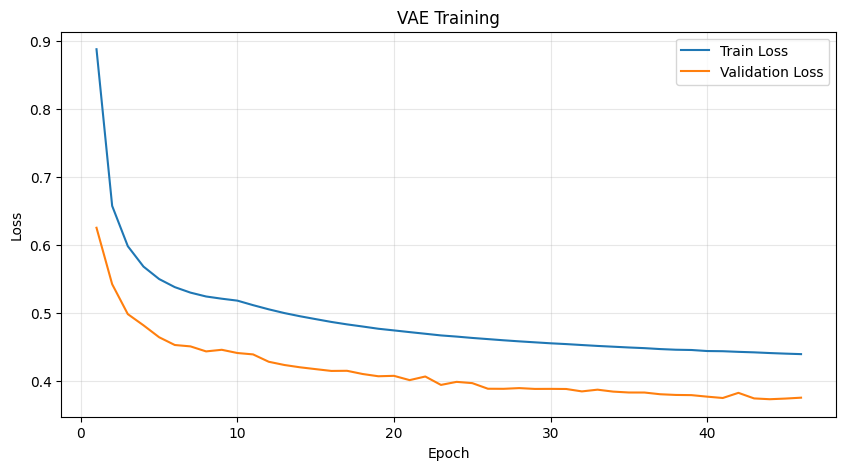

In [40]:
# ============================================================
# 40. TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)


plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "VAE Training"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Ячейка 40 — Recon и KL

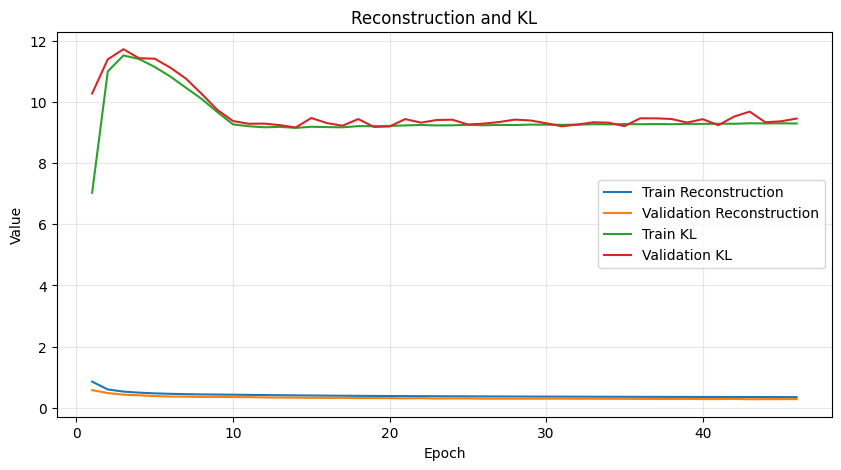

In [41]:
# ============================================================
# 41. RECONSTRUCTION + KL
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_recon"],
    label="Train Reconstruction"
)


plt.plot(
    history_df["epoch"],
    history_df["val_recon"],
    label="Validation Reconstruction"
)


plt.plot(
    history_df["epoch"],
    history_df["train_kl"],
    label="Train KL"
)


plt.plot(
    history_df["epoch"],
    history_df["val_kl"],
    label="Validation KL"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Value"
)

plt.title(
    "Reconstruction and KL"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Ячейка 41 — статистика latent space

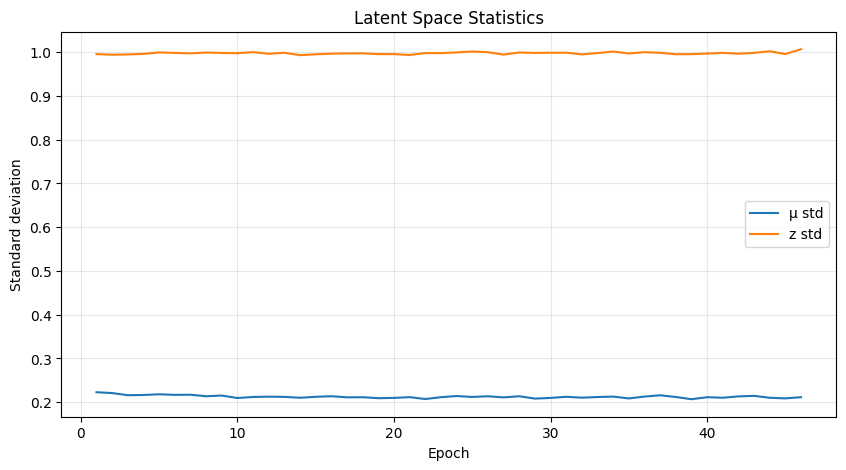

In [42]:
# ============================================================
# 42. LATENT SPACE STATISTICS
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["mu_std"],
    label="μ std"
)


plt.plot(
    history_df["epoch"],
    history_df["z_std"],
    label="z std"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Standard deviation"
)

plt.title(
    "Latent Space Statistics"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

=============================================================================================================================
=============================================================================================================================
=============================================================================================================================

In [49]:
# ============================================================
# ГЕНЕРАЦИЯ 5000 МОЛЕКУЛ ПО ЦЕЛЕВЫМ ДЕСКРИПТОРАМ
# TARGET-DESCRIPTOR-CONDITIONED MOLECULE GENERATION
# ============================================================


import os
import random
import numpy as np
import torch

from rdkit import Chem
from rdkit import RDLogger

import selfies as sf


# ============================================================
# RDKit
# ============================================================

RDLogger.DisableLog("rdApp.*")


# ============================================================
# НАСТРОЙКИ
# ============================================================

CHECKPOINT_DIR = "checkpoints_vae"

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "vae_best_transformer_conditional.pt"
)


N_SAMPLES = 5000

SEED = 42

MAX_LEN = 66

LATENT_DIM = 128

BATCH_SIZE_GEN = 256

TEMPERATURE = 1.0


# ============================================================
# СПЕЦИАЛЬНЫЕ ТОКЕНЫ
# ============================================================

PAD_IDX = 0
START_IDX = 1
END_IDX = 2
UNK_IDX = 3


# ============================================================
# ДЕСКРИПТОРЫ
# ============================================================

PROPERTY_NAMES = [

    "logP",
    "QED",
    "SAS",
    "MW",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3"

]


PROPERTY_DIM = len(
    PROPERTY_NAMES
)


# ============================================================
# ЦЕЛЕВЫЕ ДЕСКРИПТОРЫ
# ============================================================
#
# Можно задавать только те свойства,
# которыми необходимо управлять.
#
# Остальные свойства автоматически получают
# средние значения TRAIN.
#
# ============================================================
#
# Пример:
#
# TARGET_PROPERTIES = {
#     "logP": 2.5
# }
#
#
# Несколько свойств:
#
# TARGET_PROPERTIES = {
#     "logP": 2.5,
#     "MW": 350.0,
#     "TPSA": 80.0
# }
#
#
# Все свойства:
#
# TARGET_PROPERTIES = {
#     "logP": 2.5,
#     "QED": 0.75,
#     "SAS": 3.0,
#     "MW": 330.0,
#     "TPSA": 64.0,
#     "HBD": 1.0,
#     "HBA": 4.0,
#     "RotatableBonds": 4.0,
#     "Rings": 3.0,
#     "AromaticRings": 2.0,
#     "FractionCSP3": 0.42
# }
#
# ============================================================

TARGET_PROPERTIES = {

    "logP": 2.5

}


# ============================================================
# ПРОВЕРКА TARGET DESCRIPTORS
# ============================================================

unknown_properties = [

    name
    for name in TARGET_PROPERTIES
    if name not in PROPERTY_NAMES

]


if len(unknown_properties) > 0:

    raise ValueError(

        "Обнаружены неизвестные дескрипторы:\n"
        + "\n".join(unknown_properties)
        + "\n\n"
        "Допустимые дескрипторы:\n"
        + "\n".join(PROPERTY_NAMES)

    )


# ============================================================
# ПРОВЕРКА ОСНОВНЫХ ОБЪЕКТОВ
# ============================================================

required_variables = [

    "df_vae",
    "train_indices",
    "features",
    "idx_to_token",
    "model"

]


missing_variables = [

    name
    for name in required_variables
    if name not in globals()

]


if len(missing_variables) > 0:

    raise RuntimeError(

        "В ноутбуке отсутствуют необходимые переменные:\n\n"
        + "\n".join(missing_variables)
        + "\n\n"
        "Сначала выполните соответствующие ячейки "
        "подготовки данных и модели."

    )


# ============================================================
# ПРОВЕРКА FEATURES
# ============================================================
#
# ВАЖНО:
#
# При обучении использовался массив:
#
#     features
#
# размерности:
#
#     [N, 11]
#
# Поэтому TRAIN statistics необходимо получать
# именно из features, а НЕ из df_vae.
#
# ============================================================

if not isinstance(
    features,
    np.ndarray
):

    features = np.asarray(
        features,
        dtype=np.float32
    )


if features.ndim != 2:

    raise ValueError(

        f"features должен быть двумерным массивом. "
        f"Получена размерность: {features.shape}"

    )


if features.shape[1] != PROPERTY_DIM:

    raise ValueError(

        f"Несоответствие числа дескрипторов:\n\n"
        f"PROPERTY_DIM = {PROPERTY_DIM}\n"
        f"features.shape[1] = {features.shape[1]}"

    )


if len(features) != len(df_vae):

    raise ValueError(

        f"Несоответствие количества молекул:\n\n"
        f"len(df_vae) = {len(df_vae)}\n"
        f"len(features) = {len(features)}"

    )


if not np.isfinite(features).all():

    raise ValueError(
        "В features обнаружены NaN или Inf."
    )


# ============================================================
# ПРОВЕРКА TRAIN INDICES
# ============================================================

train_indices = np.asarray(
    train_indices
)


if len(train_indices) == 0:

    raise ValueError(
        "train_indices пуст."
    )


if train_indices.min() < 0:

    raise ValueError(
        "train_indices содержит отрицательные индексы."
    )


if train_indices.max() >= len(features):

    raise ValueError(

        "train_indices содержит индекс "
        "за пределами features."

    )


# ============================================================
# TRAIN FEATURES
# ============================================================

train_features = features[
    train_indices
]


# ============================================================
# TRAIN PROPERTY MEANS
# ============================================================
#
# Используем ТОЧНО тот же набор из 11 дескрипторов,
# который использовался при обучении.
#
# ============================================================

TRAIN_PROPERTY_MEANS = {

    name: float(
        np.mean(
            train_features[:, i]
        )
    )

    for i, name in enumerate(
        PROPERTY_NAMES
    )

}


# ============================================================
# ПРОВЕРКА TRAIN PROPERTY MEANS
# ============================================================

if not all(

    np.isfinite(value)
    for value in TRAIN_PROPERTY_MEANS.values()

):

    raise ValueError(
        "В TRAIN_PROPERTY_MEANS обнаружены NaN или Inf."
    )


# ============================================================
# TRAIN PROPERTY STATISTICS
# ============================================================

print()
print("=" * 70)
print("TRAIN PROPERTY MEANS")
print("=" * 70)

print()

for name in PROPERTY_NAMES:

    print(

        f"{name:20s}: "
        f"{TRAIN_PROPERTY_MEANS[name]:10.4f}"

    )


# ============================================================
# ФОРМИРОВАНИЕ ПОЛНОГО TARGET ВЕКТОРА
# ============================================================
#
# Пользователь задаёт только необходимые свойства.
#
# Все остальные:
#
#     → среднее значение TRAIN
#
# ============================================================

target_properties_full = {}


for name in PROPERTY_NAMES:

    if name in TARGET_PROPERTIES:

        target_properties_full[name] = float(
            TARGET_PROPERTIES[name]
        )

    else:

        target_properties_full[name] = (
            TRAIN_PROPERTY_MEANS[name]
        )


# ============================================================
# TARGET DESCRIPTORS
# ============================================================

print()
print("=" * 70)
print("TARGET DESCRIPTORS")
print("=" * 70)

print()

print(
    "USER       = задано пользователем"
)

print(
    "TRAIN MEAN = среднее значение TRAIN"
)

print()


for name in PROPERTY_NAMES:

    if name in TARGET_PROPERTIES:

        source = "USER"

    else:

        source = "TRAIN MEAN"


    print(

        f"{name:20s}: "
        f"{target_properties_full[name]:10.4f} "
        f"[{source}]"

    )


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)


# ============================================================
# SEED
# ============================================================

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


# ============================================================
# GENERATION SETTINGS
# ============================================================

print()
print("=" * 70)
print("GENERATION SETTINGS")
print("=" * 70)

print(
    f"Device:       {DEVICE}"
)

print(
    f"N samples:    {N_SAMPLES}"
)

print(
    f"Latent dim:   {LATENT_DIM}"
)

print(
    f"Max length:   {MAX_LEN}"
)

print(
    f"Temperature:  {TEMPERATURE}"
)

print(
    f"Batch size:   {BATCH_SIZE_GEN}"
)


# ============================================================
# ПРОВЕРКА CHECKPOINT
# ============================================================

if not os.path.exists(
    CHECKPOINT_PATH
):

    raise FileNotFoundError(

        f"\nConditional checkpoint не найден:\n"
        f"{CHECKPOINT_PATH}\n\n"

        "Сначала необходимо обучить "
        "conditional VAE модель."

    )


print()
print(
    f"Checkpoint найден:\n{CHECKPOINT_PATH}"
)


# ============================================================
# ЗАГРУЗКА CHECKPOINT
# ============================================================

checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=DEVICE,

    weights_only=False

)


print()
print(
    "Checkpoint загружен."
)


# ============================================================
# CHECKPOINT INFORMATION
# ============================================================

if isinstance(
    checkpoint,
    dict
):

    print()
    print(
        "Ключи checkpoint:"
    )

    print(
        list(
            checkpoint.keys()
        )
    )


# ============================================================
# PROPERTY SCALER
# ============================================================

if (

    isinstance(
        checkpoint,
        dict
    )

    and

    "property_scaler"
    in checkpoint

):

    property_scaler = (

        checkpoint[
            "property_scaler"
        ]

    )


    print()
    print(
        "Property scaler загружен "
        "из checkpoint."
    )


else:

    raise KeyError(

        "\nВ checkpoint отсутствует "
        "'property_scaler'.\n\n"

        "Для conditional generation необходимо "
        "использовать scaler, применявшийся "
        "при обучении."

    )


# ============================================================
# ПРОВЕРКА SCALER
# ============================================================

if not hasattr(
    property_scaler,
    "n_features_in_"
):

    raise ValueError(
        "Некорректный property_scaler."
    )


if property_scaler.n_features_in_ != PROPERTY_DIM:

    raise ValueError(

        f"\nScaler ожидает "
        f"{property_scaler.n_features_in_} "
        f"признаков,\n"
        f"но PROPERTY_DIM = {PROPERTY_DIM}."

    )


# ============================================================
# ЗАГРУЗКА ВЕСОВ МОДЕЛИ
# ============================================================

if (

    isinstance(
        checkpoint,
        dict
    )

    and

    "model_state_dict"
    in checkpoint

):

    model.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]

    )


    print()
    print(
        "Загружен model_state_dict."
    )


elif (

    isinstance(
        checkpoint,
        dict
    )

    and

    "state_dict"
    in checkpoint

):

    model.load_state_dict(

        checkpoint[
            "state_dict"
        ]

    )


    print()
    print(
        "Загружен state_dict."
    )


else:

    model.load_state_dict(
        checkpoint
    )


    print()
    print(
        "Checkpoint загружен "
        "непосредственно как state_dict."
    )


# ============================================================
# MODEL
# ============================================================

model = model.to(
    DEVICE
)

model.eval()


print()
print(
    "Модель переведена "
    "в evaluation mode."
)


# ============================================================
# ПРОВЕРКА MODEL DIMENSIONS
# ============================================================

model_property_dim = (

    model
    .decoder
    .property_projection[0]
    .in_features

)


model_latent_dim = (

    model
    .decoder
    .latent_projection
    .in_features

)


if model_property_dim != PROPERTY_DIM:

    raise ValueError(

        f"\nНесоответствие property dimension:\n"
        f"PROPERTY_DIM = {PROPERTY_DIM}\n"
        f"Model expects = {model_property_dim}"

    )


if model_latent_dim != LATENT_DIM:

    raise ValueError(

        f"\nНесоответствие latent dimension:\n"
        f"LATENT_DIM = {LATENT_DIM}\n"
        f"Model expects = {model_latent_dim}"

    )


# ============================================================
# VOCABULARY
# ============================================================

VOCAB_SIZE = (

    model
    .decoder
    .embedding
    .num_embeddings

)


print()
print(
    f"Vocabulary size: {VOCAB_SIZE}"
)


if VOCAB_SIZE <= END_IDX:

    raise ValueError(
        "Размер vocabulary слишком мал."
    )


# ============================================================
# TARGET → NUMPY
# ============================================================

target_property_array = np.array(

    [
        target_properties_full[name]
        for name in PROPERTY_NAMES
    ],

    dtype=np.float32

)


if target_property_array.shape != (
    PROPERTY_DIM,
):

    raise ValueError(

        f"Неверная размерность target vector: "
        f"{target_property_array.shape}"

    )


# ============================================================
# TARGET → SCALED
# ============================================================
#
# Используем ТОТ ЖЕ scaler,
# который был сохранён при обучении.
#
# ============================================================

target_properties_scaled = (

    property_scaler.transform(

        target_property_array.reshape(
            1,
            -1
        )

    )

)


target_properties_scaled = (

    target_properties_scaled
    .astype(np.float32)

)


# ============================================================
# SCALED TARGET
# ============================================================

print()
print("=" * 70)
print("SCALED TARGET DESCRIPTORS")
print("=" * 70)

print()


for name, value in zip(

    PROPERTY_NAMES,

    target_properties_scaled[0]

):

    print(

        f"{name:20s}: "
        f"{value:10.6f}"

    )


# ============================================================
# TARGET → TORCH
# ============================================================

target_properties_tensor = torch.tensor(

    target_properties_scaled,

    dtype=torch.float32,

    device=DEVICE

)


# ============================================================
# TOKEN IDS → SELFIES
# ============================================================

def tokens_to_selfies(

    token_ids,
    idx_to_token

):

    """
    Преобразование последовательности
    token IDs в SELFIES.
    """

    tokens = []


    for idx in token_ids:

        idx = int(idx)


        # ----------------------------------------------------
        # END
        # ----------------------------------------------------

        if idx == END_IDX:

            break


        # ----------------------------------------------------
        # PAD / START
        # ----------------------------------------------------

        if idx in (

            PAD_IDX,
            START_IDX

        ):

            continue


        # ----------------------------------------------------
        # TOKEN
        # ----------------------------------------------------

        token = idx_to_token.get(

            idx,
            "<UNK>"

        )


        if token == "<UNK>":

            return None


        tokens.append(
            token
        )


    # --------------------------------------------------------
    # Пустая последовательность
    # --------------------------------------------------------

    if len(tokens) == 0:

        return None


    return "".join(
        tokens
    )


# ============================================================
# АВТОРЕГРЕССИВНАЯ ГЕНЕРАЦИЯ
# ============================================================

@torch.no_grad()
def generate_batch(

    model,
    z,
    target_properties,
    max_len=MAX_LEN,
    temperature=TEMPERATURE

):

    """
    Генерация SELFIES для batch латентных
    векторов z при заданных target descriptors.
    """

    batch_size = z.size(0)


    # ========================================================
    # TEMPERATURE
    # ========================================================

    if temperature <= 0:

        raise ValueError(
            "Temperature должна быть > 0."
        )


    # ========================================================
    # START TOKEN
    # ========================================================

    generated = torch.full(

        (
            batch_size,
            1
        ),

        START_IDX,

        dtype=torch.long,

        device=z.device

    )


    # ========================================================
    # FINISHED
    # ========================================================

    finished = torch.zeros(

        batch_size,

        dtype=torch.bool,

        device=z.device

    )


    # ========================================================
    # AUTOREGRESSIVE GENERATION
    # ========================================================

    for step in range(

        max_len - 1

    ):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        logits = model.decoder(

            generated,

            z,

            target_properties

        )


        # ----------------------------------------------------
        # Последний timestep
        # ----------------------------------------------------

        next_token_logits = (

            logits[:, -1, :]

        )


        # ----------------------------------------------------
        # Temperature
        # ----------------------------------------------------

        probs = torch.softmax(

            next_token_logits
            / temperature,

            dim=-1

        )


        # ----------------------------------------------------
        # Sampling
        # ----------------------------------------------------

        next_token = torch.multinomial(

            probs,

            num_samples=1

        )


        # ----------------------------------------------------
        # PAD после END
        # ----------------------------------------------------

        next_token = torch.where(

            finished.unsqueeze(1),

            torch.full_like(

                next_token,

                PAD_IDX

            ),

            next_token

        )


        # ----------------------------------------------------
        # Добавление токена
        # ----------------------------------------------------

        generated = torch.cat(

            [

                generated,
                next_token

            ],

            dim=1

        )


        # ----------------------------------------------------
        # END
        # ----------------------------------------------------

        finished |= (

            next_token.squeeze(1)
            == END_IDX

        )


        # ----------------------------------------------------
        # Все последовательности завершены
        # ----------------------------------------------------

        if finished.all():

            break


    return generated


# ============================================================
# ГЕНЕРАЦИЯ
# ============================================================

all_token_sequences = []


print()
print("=" * 70)
print("НАЧАЛО ГЕНЕРАЦИИ")
print("=" * 70)


with torch.no_grad():

    for start in range(

        0,

        N_SAMPLES,

        BATCH_SIZE_GEN

    ):

        current_batch = min(

            BATCH_SIZE_GEN,

            N_SAMPLES - start

        )


        # ----------------------------------------------------
        # z ~ N(0, I)
        # ----------------------------------------------------

        z = torch.randn(

            current_batch,

            LATENT_DIM,

            device=DEVICE

        )


        # ----------------------------------------------------
        # TARGET PROPERTIES
        # ----------------------------------------------------

        batch_target_properties = (

            target_properties_tensor.expand(

                current_batch,
                -1

            )

        )


        # ----------------------------------------------------
        # GENERATION
        # ----------------------------------------------------

        generated_tokens = generate_batch(

            model=model,

            z=z,

            target_properties=(
                batch_target_properties
            )

        )


        all_token_sequences.extend(

            generated_tokens
            .cpu()
            .tolist()

        )


        done = (

            start
            + current_batch

        )


        if (

            done % 1024 < BATCH_SIZE_GEN

            or

            done == N_SAMPLES

        ):

            print(

                f"Generated: "
                f"{done:5d} / "
                f"{N_SAMPLES}"

            )


print()
print("-" * 70)
print(
    "Генерация завершена."
)


# ============================================================
# TOKEN SEQUENCES → SELFIES
# ============================================================

generated_selfies = []


for token_ids in all_token_sequences:

    selfies_string = tokens_to_selfies(

        token_ids,

        idx_to_token

    )


    generated_selfies.append(
        selfies_string
    )


# ============================================================
# SELFIES → SMILES
# ============================================================

generated_smiles = []

valid_smiles = []

invalid_selfies = 0

selfies_decode_errors = 0


for selfies_string in generated_selfies:

    # --------------------------------------------------------
    # Некорректная token sequence
    # --------------------------------------------------------

    if selfies_string is None:

        generated_smiles.append(
            None
        )

        invalid_selfies += 1

        continue


    # --------------------------------------------------------
    # SELFIES decoder
    # --------------------------------------------------------

    try:

        smiles = sf.decoder(
            selfies_string
        )

    except Exception:

        generated_smiles.append(
            None
        )

        selfies_decode_errors += 1

        continue


    generated_smiles.append(
        smiles
    )


    # --------------------------------------------------------
    # RDKit validation
    # --------------------------------------------------------

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is not None:

        valid_smiles.append(
            smiles
        )


# ============================================================
# CANONICAL SMILES
# ============================================================

canonical_smiles = []


for smiles in valid_smiles:

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        continue


    canonical = Chem.MolToSmiles(

        mol,

        canonical=True

    )


    canonical_smiles.append(
        canonical
    )


# ============================================================
# UNIQUE MOLECULES
# ============================================================

unique_smiles = set(
    canonical_smiles
)


# ============================================================
# STATISTICS
# ============================================================

n_generated = len(
    generated_selfies
)

n_valid = len(
    valid_smiles
)

n_unique = len(
    unique_smiles
)


validity = (

    100.0
    * n_valid
    / n_generated

    if n_generated > 0

    else 0.0

)


uniqueness = (

    100.0
    * n_unique
    / n_valid

    if n_valid > 0

    else 0.0

)


# ============================================================
# RESULTS
# ============================================================

print()
print("=" * 70)
print("РЕЗУЛЬТАТЫ CONDITIONAL GENERATION")
print("=" * 70)

print()

print(
    f"Всего сгенерировано:       "
    f"{n_generated}"
)

print(
    f"SELFIES без токенов:       "
    f"{invalid_selfies}"
)

print(
    f"SELFIES decode errors:     "
    f"{selfies_decode_errors}"
)

print(
    f"Валидных SMILES:           "
    f"{n_valid}"
)

print(
    f"Уникальных молекул:        "
    f"{n_unique}"
)

print()

print(
    f"Validity:                  "
    f"{validity:.2f}%"
)

print(
    f"Uniqueness:                "
    f"{uniqueness:.2f}%"
)


# ============================================================
# ПРИМЕРЫ МОЛЕКУЛ
# ============================================================

print()
print("=" * 70)
print("ПРИМЕРЫ СГЕНЕРИРОВАННЫХ МОЛЕКУЛ")
print("=" * 70)

print()


for i, smiles in enumerate(

    canonical_smiles[:20],

    1

):

    print(
        f"{i:2d}. {smiles}"
    )


# ============================================================
# TARGET DESCRIPTORS
# ============================================================

print()
print("=" * 70)
print("TARGET DESCRIPTORS ДЛЯ ЭТОЙ ГЕНЕРАЦИИ")
print("=" * 70)

print()


for name in PROPERTY_NAMES:

    if name in TARGET_PROPERTIES:

        source = "USER"

    else:

        source = "TRAIN MEAN"


    print(

        f"{name:20s}: "
        f"{target_properties_full[name]:10.4f} "
        f"[{source}]"

    )


# ============================================================
# ГЕНЕРАЦИЯ ЗАВЕРШЕНА
# ============================================================

print()
print("=" * 70)
print("ГЕНЕРАЦИЯ ЗАВЕРШЕНА")
print("=" * 70)


TRAIN PROPERTY MEANS

logP                :     2.3970
QED                 :     0.7351
SAS                 :     3.0621
MW                  :   329.5331
TPSA                :    63.9482
HBD                 :     1.1556
HBA                 :     3.9022
RotatableBonds      :     4.5620
Rings               :     2.7214
AromaticRings       :     1.8192
FractionCSP3        :     0.4179

TARGET DESCRIPTORS

USER       = задано пользователем
TRAIN MEAN = среднее значение TRAIN

logP                :     2.5000 [USER]
QED                 :     0.7351 [TRAIN MEAN]
SAS                 :     3.0621 [TRAIN MEAN]
MW                  :   329.5331 [TRAIN MEAN]
TPSA                :    63.9482 [TRAIN MEAN]
HBD                 :     1.1556 [TRAIN MEAN]
HBA                 :     3.9022 [TRAIN MEAN]
RotatableBonds      :     4.5620 [TRAIN MEAN]
Rings               :     2.7214 [TRAIN MEAN]
AromaticRings       :     1.8192 [TRAIN MEAN]
FractionCSP3        :     0.4179 [TRAIN MEAN]

GENERATION SETTINGS
D

In [50]:
# ============================================================
# ПРОВЕРКА CONDITIONAL GENERATION
#
# Цель:
# 1. Проверить валидность и уникальность.
# 2. Проверить соответствие target descriptors.
# 3. Проверить, влияет ли target condition на генерацию.
# 4. Проверить влияние каждого из 11 дескрипторов.
# 5. Провести controlled experiment:
#    одинаковые latent z + разные target properties.
#
# ВАЖНО:
# Для корректной проверки используется ОДИН И ТОТ ЖЕ
# набор latent vectors z для разных условий.
#
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from rdkit import Chem
from rdkit.Chem import (
    Descriptors,
    Crippen,
    QED,
    Lipinski,
    rdMolDescriptors
)

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tqdm.auto import tqdm


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

SEED = 42

N_SAMPLES = 1000

TEMPERATURE = 1.0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("ПРОВЕРКА CONDITIONAL GENERATION")
print("=" * 70)

print("Device:", DEVICE)
print("N_SAMPLES:", N_SAMPLES)
print("Temperature:", TEMPERATURE)


# ============================================================
# 2. SEED
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 3. 11 ДЕСКРИПТОРОВ
# ============================================================

PROPERTY_NAMES = [
    "logP",
    "QED",
    "SAS",
    "MW",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3"
]

PROPERTY_DIM = len(PROPERTY_NAMES)

assert PROPERTY_DIM == 11


# ============================================================
# 4. ПРОВЕРКА НЕОБХОДИМЫХ ОБЪЕКТОВ
# ============================================================

required_objects = [
    "model",
    "features",
    "train_indices",
    "idx_to_token",
    "property_scaler",
    "MAX_LEN"
]

print()
print("Проверка объектов:")

for name in required_objects:

    if name not in globals():

        raise RuntimeError(
            f"Объект '{name}' отсутствует в памяти Jupyter."
        )

    print(f"  ✓ {name}")


# ============================================================
# 5. ПРОВЕРКА FEATURES
# ============================================================

features = np.asarray(
    features,
    dtype=np.float32
)

print()
print("features:", features.shape)

assert features.ndim == 2

assert features.shape[1] == PROPERTY_DIM

assert np.isfinite(features).all()

print("✓ features содержит все 11 дескрипторов")


# ============================================================
# 6. TRAIN MEANS
#
# Используются только для незаданных параметров.
# ============================================================

train_indices_np = np.asarray(
    train_indices,
    dtype=np.int64
)

train_features = features[
    train_indices_np
]

TRAIN_PROPERTY_MEANS = np.mean(
    train_features,
    axis=0
)

train_mean_dict = dict(
    zip(
        PROPERTY_NAMES,
        TRAIN_PROPERTY_MEANS
    )
)

print()
print("TRAIN PROPERTY MEANS")
print("-" * 70)

for name, value in train_mean_dict.items():

    print(
        f"{name:<20} {value:10.4f}"
    )


# ============================================================
# 7. RDKit DESCRIPTORS
# ============================================================

def calculate_descriptors(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    values = {}

    values["logP"] = Crippen.MolLogP(mol)

    values["QED"] = QED.qed(mol)

    values["SAS"] = np.nan

    values["MW"] = Descriptors.MolWt(mol)

    values["TPSA"] = rdMolDescriptors.CalcTPSA(mol)

    values["HBD"] = Lipinski.NumHDonors(mol)

    values["HBA"] = Lipinski.NumHAcceptors(mol)

    values["RotatableBonds"] = (
        Lipinski.NumRotatableBonds(mol)
    )

    values["Rings"] = (
        rdMolDescriptors.CalcNumRings(mol)
    )

    values["AromaticRings"] = (
        rdMolDescriptors.CalcNumAromaticRings(mol)
    )

    values["FractionCSP3"] = (
        rdMolDescriptors.CalcFractionCSP3(mol)
    )

    return values


# ============================================================
# 8. SAS
# ============================================================
#
# SAS требует RDKit Contrib SA_Score.
# Если он доступен, рассчитываем его.
#
# ============================================================

try:

    import sys

    sa_path = os.path.join(
        os.path.dirname(
            __import__("rdkit").__file__
        ),
        "Contrib",
        "SA_Score"
    )

    if os.path.exists(sa_path):

        sys.path.append(sa_path)

        import sascorer

        SAS_AVAILABLE = True

        print()
        print("✓ SAS доступен")

    else:

        SAS_AVAILABLE = False

        print()
        print("⚠ SAS_Score не найден")

except Exception as e:

    SAS_AVAILABLE = False

    print()
    print(
        "⚠ SAS недоступен:",
        e
    )


# ============================================================
# 9. ФУНКЦИЯ СКОРИНГА
# ============================================================

def calculate_all_descriptors(smiles):

    values = calculate_descriptors(smiles)

    if values is None:
        return None

    mol = Chem.MolFromSmiles(smiles)

    if SAS_AVAILABLE:

        try:
            values["SAS"] = sascorer.calculateScore(mol)

        except Exception:
            values["SAS"] = np.nan

    return values


# ============================================================
# 10. GENERATION FUNCTION
# ============================================================

def generate_conditioned(
    model,
    z,
    target_properties,
    temperature=1.0
):

    model.eval()

    device = next(
        model.parameters()
    ).device

    # --------------------------------------------------------
    # target properties
    # --------------------------------------------------------

    target_vector = np.array(
        [
            target_properties[name]
            for name in PROPERTY_NAMES
        ],
        dtype=np.float32
    )

    target_scaled = property_scaler.transform(
        target_vector.reshape(1, -1)
    )

    target_scaled = torch.tensor(
        target_scaled,
        dtype=torch.float32,
        device=device
    )

    target_scaled = target_scaled.repeat(
        z.shape[0],
        1
    )

    batch_size = z.shape[0]

    # --------------------------------------------------------
    # START TOKEN
    # --------------------------------------------------------

    START_IDX = 1
    END_IDX = 2

    generated = torch.full(
        (batch_size, 1),
        START_IDX,
        dtype=torch.long,
        device=device
    )

    # --------------------------------------------------------
    # AUTOREGRESSIVE GENERATION
    # --------------------------------------------------------

    with torch.no_grad():

        for step in range(
            MAX_LEN - 1
        ):

            logits = model.decoder(
                generated,
                z,
                target_properties=target_scaled
            )

            next_logits = logits[:, -1, :]

            next_logits = (
                next_logits / temperature
            )

            probabilities = torch.softmax(
                next_logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            )

            generated = torch.cat(
                [
                    generated,
                    next_token
                ],
                dim=1
            )

            # ------------------------------------------------
            # STOP IF ALL END
            # ------------------------------------------------

            if torch.all(
                next_token.squeeze(1) == END_IDX
            ):

                break

    return generated


# ============================================================
# 11. TOKENS → SELFIES
# ============================================================

def tokens_to_selfies(tokens):

    tokens = tokens.detach().cpu().numpy()

    result = []

    for sequence in tokens:

        token_list = []

        for token_id in sequence:

            token = idx_to_token.get(
                int(token_id),
                "<UNK>"
            )

            if token == "<START>":
                continue

            if token == "<END>":
                break

            if token == "<PAD>":
                continue

            if token == "<UNK>":
                continue

            token_list.append(token)

        result.append(
            "".join(token_list)
        )

    return result


# ============================================================
# 12. SELFIES → SMILES
# ============================================================

import selfies as sf


def selfies_to_smiles(
    selfies_list
):

    smiles_list = []

    for s in selfies_list:

        try:

            smiles = sf.decoder(s)

            smiles_list.append(smiles)

        except Exception:

            smiles_list.append(None)

    return smiles_list


# ============================================================
# 13. CANONICAL SMILES
# ============================================================

def canonicalize(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(
        mol,
        canonical=True
    )


# ============================================================
# 14. СОЗДАЁМ ОДИН И ТОТ ЖЕ Z
#
# Это КРИТИЧЕСКАЯ часть эксперимента.
#
# Для каждого условия используется один и тот же z.
#
# ============================================================

model = model.to(DEVICE)
model.eval()

latent_dim = (
    model.encoder.fc_mu.out_features
)

print()
print("Latent dimension:", latent_dim)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

z_test = torch.randn(
    N_SAMPLES,
    latent_dim,
    device=DEVICE
)

print(
    "Latent vectors:",
    tuple(z_test.shape)
)


# ============================================================
# 15. EXPERIMENT 1
#
# ВЛИЯНИЕ LOGP
#
# Остальные параметры = TRAIN MEAN
# ============================================================

LOGP_TARGETS = [
    1.0,
    2.0,
    3.0,
    4.0,
    5.0
]

print()
print("=" * 70)
print("EXPERIMENT 1: ВЛИЯНИЕ TARGET logP")
print("=" * 70)


logp_results = []

all_conditioned_smiles = {}

for target_logp in LOGP_TARGETS:

    print()
    print(
        f"Target logP = {target_logp}"
    )

    target = train_mean_dict.copy()

    target["logP"] = target_logp

    generated_tokens = generate_conditioned(
        model=model,
        z=z_test,
        target_properties=target,
        temperature=TEMPERATURE
    )

    selfies_list = tokens_to_selfies(
        generated_tokens
    )

    smiles_list = selfies_to_smiles(
        selfies_list
    )

    valid_smiles = []

    for smiles in smiles_list:

        if smiles is None:
            continue

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is not None:
            valid_smiles.append(
                smiles
            )

    all_conditioned_smiles[
        f"logP_{target_logp}"
    ] = valid_smiles

    print(
        "Generated:",
        len(smiles_list)
    )

    print(
        "Valid:",
        len(valid_smiles),
        f"({len(valid_smiles) / len(smiles_list) * 100:.2f}%)"
    )

    if len(valid_smiles) == 0:
        continue

    values = []

    for smiles in tqdm(
        valid_smiles,
        desc="Descriptors",
        leave=False
    ):

        d = calculate_all_descriptors(
            smiles
        )

        if d is not None:
            values.append(d)

    df_values = pd.DataFrame(
        values
    )

    generated_mean = (
        df_values["logP"]
        .mean()
    )

    generated_median = (
        df_values["logP"]
        .median()
    )

    mae = mean_absolute_error(
        np.full(
            len(df_values),
            target_logp
        ),
        df_values["logP"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            np.full(
                len(df_values),
                target_logp
            ),
            df_values["logP"]
        )
    )

    logp_results.append(
        {
            "target_logP": target_logp,
            "n_valid": len(valid_smiles),
            "generated_mean_logP":
                generated_mean,
            "generated_median_logP":
                generated_median,
            "MAE":
                mae,
            "RMSE":
                rmse
        }
    )

    print(
        f"Generated mean logP: "
        f"{generated_mean:.4f}"
    )

    print(
        f"Generated median logP: "
        f"{generated_median:.4f}"
    )

    print(
        f"MAE: {mae:.4f}"
    )

    print(
        f"RMSE: {rmse:.4f}"
    )


# ============================================================
# 16. LOGP RESULTS TABLE
# ============================================================

df_logp = pd.DataFrame(
    logp_results
)

print()
print("=" * 70)
print("RESULTS: TARGET logP → GENERATED logP")
print("=" * 70)

display(
    df_logp
)


# ============================================================
# 17. КОРРЕЛЯЦИЯ TARGET → GENERATED
# ============================================================

if len(df_logp) >= 3:

    pearson_r, pearson_p = pearsonr(
        df_logp["target_logP"],
        df_logp["generated_mean_logP"]
    )

    spearman_r, spearman_p = spearmanr(
        df_logp["target_logP"],
        df_logp["generated_mean_logP"]
    )

    print()
    print(
        f"Pearson r:  {pearson_r:.4f}"
    )

    print(
        f"Pearson p:  {pearson_p:.6g}"
    )

    print(
        f"Spearman ρ: {spearman_r:.4f}"
    )

    print(
        f"Spearman p: {spearman_p:.6g}"
    )


# ============================================================
# 18. EXPERIMENT 2
#
# ПОКАЗАТЕЛЬНЫЙ TEST ДЛЯ ВСЕХ 11 ДЕСКРИПТОРОВ
#
# Для каждого свойства:
#   target = mean - delta
#   target = mean
#   target = mean + delta
#
# Остальные свойства остаются на TRAIN mean.
#
# ============================================================

print()
print("=" * 70)
print("EXPERIMENT 2: ВСЕ 11 ДЕСКРИПТОРОВ")
print("=" * 70)


# ------------------------------------------------------------
# Диапазоны воздействия
# ------------------------------------------------------------

TARGET_LEVELS = {

    "logP": [
        1.0,
        3.0,
        5.0
    ],

    "QED": [
        0.4,
        0.7,
        0.9
    ],

    "SAS": [
        2.0,
        3.5,
        5.0
    ],

    "MW": [
        250.0,
        330.0,
        450.0
    ],

    "TPSA": [
        40.0,
        70.0,
        110.0
    ],

    "HBD": [
        0.0,
        1.0,
        3.0
    ],

    "HBA": [
        2.0,
        4.0,
        7.0
    ],

    "RotatableBonds": [
        2.0,
        5.0,
        8.0
    ],

    "Rings": [
        1.0,
        3.0,
        5.0
    ],

    "AromaticRings": [
        0.0,
        2.0,
        4.0
    ],

    "FractionCSP3": [
        0.2,
        0.45,
        0.7
    ]
}


# ============================================================
# 19. RUN ALL PROPERTY TESTS
# ============================================================

all_results = []


for property_name in PROPERTY_NAMES:

    print()
    print("-" * 70)
    print(
        f"PROPERTY: {property_name}"
    )
    print("-" * 70)

    levels = TARGET_LEVELS[
        property_name
    ]

    for target_value in levels:

        target = train_mean_dict.copy()

        target[property_name] = target_value

        generated_tokens = generate_conditioned(
            model=model,
            z=z_test,
            target_properties=target,
            temperature=TEMPERATURE
        )

        selfies_list = tokens_to_selfies(
            generated_tokens
        )

        smiles_list = selfies_to_smiles(
            selfies_list
        )

        valid_smiles = []

        for smiles in smiles_list:

            if smiles is None:
                continue

            mol = Chem.MolFromSmiles(
                smiles
            )

            if mol is not None:
                valid_smiles.append(
                    smiles
                )

        descriptor_values = []

        for smiles in tqdm(
            valid_smiles,
            desc=property_name,
            leave=False
        ):

            d = calculate_all_descriptors(
                smiles
            )

            if d is not None:
                descriptor_values.append(d)

        if len(descriptor_values) == 0:

            print(
                f"Target={target_value}: "
                f"NO VALID MOLECULES"
            )

            continue

        df_values = pd.DataFrame(
            descriptor_values
        )

        actual_values = (
            df_values[property_name]
        )

        mean_actual = (
            actual_values.mean()
        )

        mae = mean_absolute_error(
            np.full(
                len(actual_values),
                target_value
            ),
            actual_values
        )

        rmse = np.sqrt(
            mean_squared_error(
                np.full(
                    len(actual_values),
                    target_value
                ),
                actual_values
            )
        )

        all_results.append(
            {
                "property":
                    property_name,

                "target":
                    target_value,

                "n_valid":
                    len(valid_smiles),

                "generated_mean":
                    mean_actual,

                "generated_median":
                    actual_values.median(),

                "MAE":
                    mae,

                "RMSE":
                    rmse
            }
        )

        print(
            f"target={target_value:8.3f} "
            f"→ mean={mean_actual:8.3f} "
            f"MAE={mae:8.3f}"
        )


# ============================================================
# 20. ОБЩАЯ ТАБЛИЦА
# ============================================================

df_all_results = pd.DataFrame(
    all_results
)

print()
print("=" * 70)
print("ОБЩИЕ РЕЗУЛЬТАТЫ")
print("=" * 70)

display(
    df_all_results
)


# ============================================================
# 21. SENSITIVITY ANALYSIS
#
# Проверяем:
#
# target ↑
# generated mean ↑ ?
#
# ============================================================

sensitivity_results = []


for property_name in PROPERTY_NAMES:

    df_property = (
        df_all_results[
            df_all_results["property"]
            == property_name
        ]
        .sort_values("target")
    )

    if len(df_property) < 3:
        continue

    targets = (
        df_property["target"]
        .to_numpy()
    )

    generated = (
        df_property["generated_mean"]
        .to_numpy()
    )

    try:

        pearson_r, pearson_p = pearsonr(
            targets,
            generated
        )

        spearman_r, spearman_p = spearmanr(
            targets,
            generated
        )

    except Exception:

        pearson_r = np.nan
        pearson_p = np.nan

        spearman_r = np.nan
        spearman_p = np.nan

    sensitivity_results.append(
        {
            "property":
                property_name,

            "Pearson_r":
                pearson_r,

            "Pearson_p":
                pearson_p,

            "Spearman_r":
                spearman_r,

            "Spearman_p":
                spearman_p,

            "target_min":
                targets.min(),

            "target_max":
                targets.max(),

            "generated_min":
                generated.min(),

            "generated_max":
                generated.max()
        }
    )


df_sensitivity = pd.DataFrame(
    sensitivity_results
)


# ============================================================
# 22. SENSITIVITY TABLE
# ============================================================

print()
print("=" * 70)
print("SENSITIVITY: ВЛИЯНИЕ TARGET НА ГЕНЕРИРУЕМОЕ СВОЙСТВО")
print("=" * 70)

display(
    df_sensitivity
)


# ============================================================
# 23. CONTROL EXPERIMENT
#
# Для одного и того же z:
#
# condition A
# condition B
#
# Проверяем, меняется ли молекула.
# ============================================================

print()
print("=" * 70)
print("CONTROL EXPERIMENT")
print("=" * 70)

control_property = "logP"

condition_A = train_mean_dict.copy()
condition_B = train_mean_dict.copy()

condition_A[control_property] = 1.0
condition_B[control_property] = 5.0


tokens_A = generate_conditioned(
    model=model,
    z=z_test,
    target_properties=condition_A,
    temperature=TEMPERATURE
)

tokens_B = generate_conditioned(
    model=model,
    z=z_test,
    target_properties=condition_B,
    temperature=TEMPERATURE
)


selfies_A = tokens_to_selfies(
    tokens_A
)

selfies_B = tokens_to_selfies(
    tokens_B
)


smiles_A = selfies_to_smiles(
    selfies_A
)

smiles_B = selfies_to_smiles(
    selfies_B
)


# ============================================================
# 24. СРАВНЕНИЕ ОДИНАКОВЫХ Z
# ============================================================

different_count = 0
same_count = 0

for a, b in zip(
    smiles_A,
    smiles_B
):

    ca = (
        canonicalize(a)
        if a is not None
        else None
    )

    cb = (
        canonicalize(b)
        if b is not None
        else None
    )

    if (
        ca is not None
        and cb is not None
    ):

        if ca == cb:
            same_count += 1

        else:
            different_count += 1


total_compared = (
    same_count
    + different_count
)

print()
print(
    "Same molecule:",
    same_count
)

print(
    "Different molecule:",
    different_count
)

if total_compared > 0:

    print(
        "Different:",
        f"{different_count / total_compared * 100:.2f}%"
    )


# ============================================================
# 25. DESCRIPTOR DISTRIBUTION
#
# Сравниваем logP для условий 1 и 5.
# ============================================================

def get_descriptor_dataframe(
    smiles_list
):

    rows = []

    for smiles in tqdm(
        smiles_list,
        leave=False
    ):

        if smiles is None:
            continue

        d = calculate_all_descriptors(
            smiles
        )

        if d is not None:
            rows.append(d)

    return pd.DataFrame(rows)


df_A = get_descriptor_dataframe(
    smiles_A
)

df_B = get_descriptor_dataframe(
    smiles_B
)


print()
print("=" * 70)
print("CONTROL: logP")
print("=" * 70)

if len(df_A) > 0:

    print(
        "Target 1.0 → generated mean:",
        f"{df_A['logP'].mean():.4f}"
    )

if len(df_B) > 0:

    print(
        "Target 5.0 → generated mean:",
        f"{df_B['logP'].mean():.4f}"
    )


# ============================================================
# 26. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================

df_logp.to_csv(
    "conditional_test_logP.csv",
    index=False
)

df_all_results.to_csv(
    "conditional_test_all_properties.csv",
    index=False
)

df_sensitivity.to_csv(
    "conditional_sensitivity.csv",
    index=False
)


print()
print("=" * 70)
print("ФАЙЛЫ СОХРАНЕНЫ")
print("=" * 70)

print(
    "conditional_test_logP.csv"
)

print(
    "conditional_test_all_properties.csv"
)

print(
    "conditional_sensitivity.csv"
)


# ============================================================
# 27. ИТОГОВАЯ ИНТЕРПРЕТАЦИЯ
# ============================================================

print()
print("=" * 70)
print("ИНТЕРПРЕТАЦИЯ")
print("=" * 70)

print(
    """
Главный критерий conditional generation:

1. При изменении target descriptor должно изменяться
   распределение соответствующего свойства.

2. Pearson / Spearman correlation должны быть положительными
   для свойств, для которых ожидается монотонная зависимость.

3. При одинаковом latent z и разных target conditions
   генерируемые молекулы должны различаться.

4. Чем сильнее target condition влияет на соответствующее
   свойство, тем выше sensitivity correlation.

5. MAE и RMSE показывают, насколько фактическое свойство
   генерируемых молекул отличается от заданного target.

ВАЖНО:

Высокая валидность сама по себе НЕ доказывает,
что conditional generation работает.

Главное доказательство — зависимость:

TARGET PROPERTY
        ↓
GENERATED PROPERTY
"""
)

ПРОВЕРКА CONDITIONAL GENERATION
Device: cuda
N_SAMPLES: 1000
Temperature: 1.0

Проверка объектов:
  ✓ model
  ✓ features
  ✓ train_indices
  ✓ idx_to_token
  ✓ property_scaler
  ✓ MAX_LEN

features: (236548, 11)
✓ features содержит все 11 дескрипторов

TRAIN PROPERTY MEANS
----------------------------------------------------------------------
logP                     2.3970
QED                      0.7351
SAS                      3.0621
MW                     329.5519
TPSA                    63.9437
HBD                      1.1556
HBA                      3.9022
RotatableBonds           4.5620
Rings                    2.7214
AromaticRings            1.8192
FractionCSP3             0.4179

✓ SAS доступен

Latent dimension: 128
Latent vectors: (1000, 128)

EXPERIMENT 1: ВЛИЯНИЕ TARGET logP

Target logP = 1.0
Generated: 1000
Valid: 1000 (100.00%)


Generated mean logP: 0.9687
Generated median logP: 0.9328
MAE: 0.7472
RMSE: 0.9437

Target logP = 2.0
Generated: 1000
Valid: 1000 (100.00%)


Generated mean logP: 1.9866
Generated median logP: 2.0595
MAE: 0.7038
RMSE: 0.8965

Target logP = 3.0
Generated: 1000
Valid: 1000 (100.00%)


Generated mean logP: 2.8143
Generated median logP: 2.8751
MAE: 0.6347
RMSE: 0.8444

Target logP = 4.0
Generated: 1000
Valid: 1000 (100.00%)


Generated mean logP: 3.5198
Generated median logP: 3.5854
MAE: 0.6687
RMSE: 0.8744

Target logP = 5.0
Generated: 1000
Valid: 1000 (100.00%)


...

,property,target,n_valid,generated_mean,generated_median,MAE,RMSE
0,logP,1.00,1000,0.928868,0.963795,0.751507,0.961206
1,logP,3.00,1000,2.897040,2.953305,0.567487,0.734590
2,logP,5.00,1000,4.178395,4.236705,0.884138,1.101455
3,QED,0.40,1000,0.600347,0.620591,0.230793,0.274543
4,QED,0.70,1000,0.707148,0.755756,0.145567,0.173145
5,QED,0.90,1000,0.798918,0.844737,0.112573,0.172625
6,SAS,2.00,1000,3.154867,2.976994,1.159595,1.463510
7,SAS,3.50,1000,4.151941,4.045805,0.755242,0.996440
8,SAS,5.00,1000,5.101961,5.060004,0.563424,0.721283
9,MW,250.00,1000,248.973882,249.314000,13.492546,19.421882



SENSITIVITY: ВЛИЯНИЕ TARGET НА ГЕНЕРИРУЕМОЕ СВОЙСТВО


,property,Pearson_r,Pearson_p,Spearman_r,Spearman_p,target_min,target_max,generated_min,generated_max
0,logP,0.992637,0.077303,1.0,0.000000,1.0,5.0,0.928868,4.178395
1,QED,0.997460,0.045380,1.0,0.000000,0.4,0.9,0.600347,0.798918
2,SAS,0.999903,0.008882,1.0,0.000000,2.0,5.0,3.154867,5.101961
3,MW,1.000000,0.000417,1.0,0.000000,250.0,450.0,248.973882,436.824618
4,TPSA,0.999993,0.002328,1.0,0.000000,40.0,110.0,43.840230,102.435710
5,HBD,0.999354,0.022887,1.0,0.000000,0.0,3.0,0.501000,2.600000
6,HBA,0.994270,0.068181,1.0,0.000000,2.0,7.0,2.851000,6.165000
7,RotatableBonds,0.999828,0.011797,1.0,0.000000,2.0,8.0,3.200000,6.876000
8,Rings,0.987692,0.099983,1.0,0.000000,1.0,5.0,1.175000,3.512000
9,AromaticRings,0.027338,0.982594,0.5,0.666667,0.0,4.0,0.686000,1.265000



CONTROL EXPERIMENT

Same molecule: 0
Different molecule: 1000
Different: 100.00%



CONTROL: logP
Target 1.0 → generated mean: 0.9997
Target 5.0 → generated mean: 4.1098

ФАЙЛЫ СОХРАНЕНЫ
conditional_test_logP.csv
conditional_test_all_properties.csv
conditional_sensitivity.csv

ИНТЕРПРЕТАЦИЯ

Главный критерий conditional generation:

1. При изменении target descriptor должно изменяться
   распределение соответствующего свойства.

2. Pearson / Spearman correlation должны быть положительными
   для свойств, для которых ожидается монотонная зависимость.

3. При одинаковом latent z и разных target conditions
   генерируемые молекулы должны различаться.

4. Чем сильнее target condition влияет на соответствующее
   свойство, тем выше sensitivity correlation.

5. MAE и RMSE показывают, насколько фактическое свойство
   генерируемых молекул отличается от заданного target.

ВАЖНО:

Высокая валидность сама по себе НЕ доказывает,
что conditional generation работает.

Главное доказательство — зависимость:

TARGET PROPERTY
        ↓
GENERATED PROPERTY



                 TRAINING

SELFIES ───────────────► Encoder ──┐
                                   ├──► z
descriptors ──► MLP ───────────────┘
                                   │
                                   │
target descriptors ──► MLP ────────┤
                                   ▼
                            Transformer Decoder
                                   │
                                   ▼
                                SELFIES

              МОЛЕКУЛА
                  │
      ┌───────────┼───────────┐
      ▼           ▼           ▼
   SELFIES   Fingerprint   Descriptors
      │           │           │
 Transformer      MLP         MLP
      │           │           │
      └───────────┼───────────┘
                  ▼
            Latent space z
                  │
                  ▼
        Transformer Decoder
                  │
                  ▼
               SELFIES